In [1]:
!pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install mygene gseapy


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 163.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 138.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 91.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 242.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 104.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 30.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 94.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 119.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 94.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/19

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.9/689.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 8.4 MB/s eta 0:00:00


In [2]:
import torch

print("GPU Device Name    :", torch.cuda.get_device_name(0))
print("Compute Capability :", torch.cuda.get_device_capability(0))
print("Supported Archs    :", torch.cuda.get_arch_list())

# Test a real tensor operation on the V100
x = torch.randn(1000, 1000, device='cuda')
y = torch.matmul(x, x)
print("✅ V100 Hardware Acceleration Confirmed Active!")

GPU Device Name    : Tesla V100-SXM2-16GB
Compute Capability : (7, 0)
Supported Archs    : ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
✅ V100 Hardware Acceleration Confirmed Active!


# Test: compare SVCCA of DINO (or Openphenom 384) vs. Novartis Drugseq

Authenticating with Colab Enterprise ADC via PyArrow...
Initializing DuckDB...
Loading DINO into memory...
Loading DRUG-seq into memory...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Applying Max-Absolute Pooling to 15020 DRUG-seq signatures...
Performing Rosetta Stone Exact Inner Join...
Initial shared chemical overlap: 4415 paired compounds.
Calculating morphological magnitudes for soft-filtering...
Dropped bottom 25% of morphological noise.
🎯 Final filtered N for CKA: 3311 highly confident pairs.

Computing True CKA between 272D Morphology and 14370D Transcriptomics...
Running 100 permutation scrambles to establish null baseline...

🧬 MULTIMODAL LATENT ALIGNMENT RESULTS
True CKA Score              : 0.1410
Null Hallucination Baseline : 0.0076
Adjusted Biological Signal  : 0.1334
Empirical P-Value           : 9.9010e-03
📊 Calculating SVCCA Axis Decay across top 100 dimensions...
🎲 Establishing null baseline via permutation...


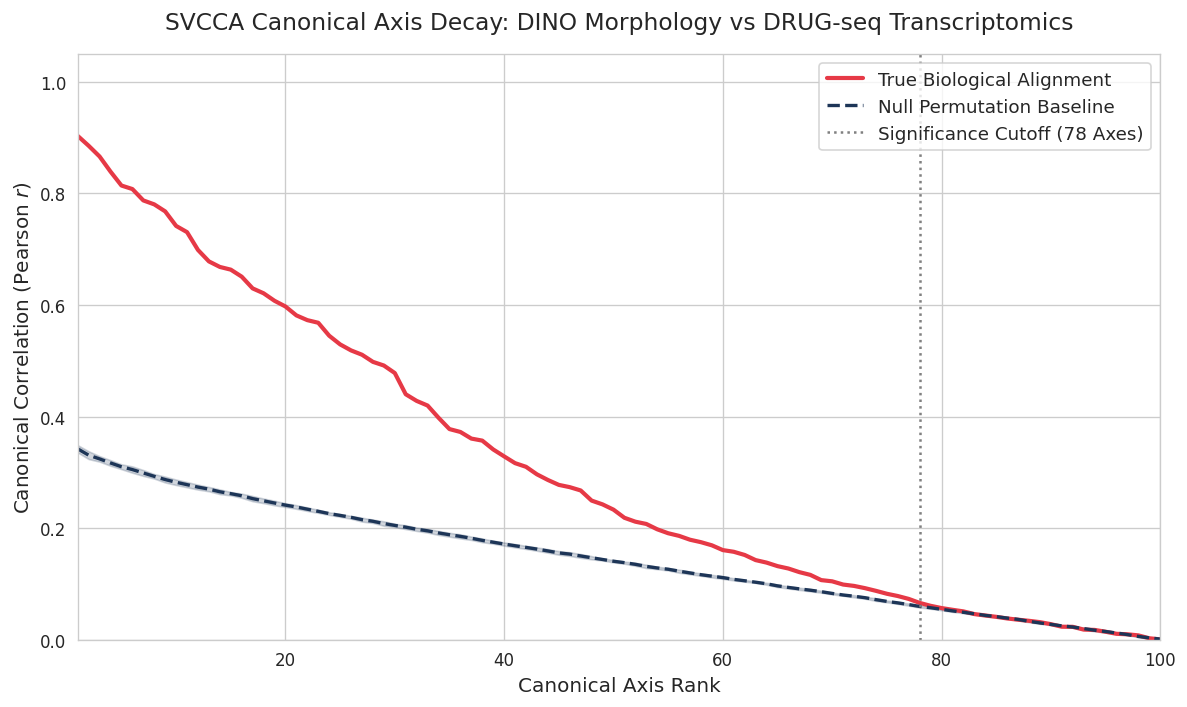


✅ Discovered 78 statistically significant axes of shared biological variance.


In [ ]:
# @title
import os
import gc
import numpy as np
import pandas as pd
import duckdb
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem

# ==============================================================================
# ⚙️ CONFIGURATION & SCHEMA MAPPING
# ==============================================================================
MERGE_KEY = "InChIKey"

#DINO_FULL_URI = "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_normed_final.parquet"
DINO_FULL_URI = 'gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384.parquet'
DRUGSEQ_URI = "gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/Novartis_U2OS_Dose_Time_Signatures.parquet"

LOCAL_DINO_CACHE = "cached_dino_full.parquet"
LOCAL_DRUGSEQ_CACHE = "cached_drugseq_24_48h.parquet"

# ==============================================================================
# 🌩️ PART I: CLOUD-TO-DISK CACHING VIA PYARROW + DUCKDB
# ==============================================================================
print("Authenticating with Colab Enterprise ADC via PyArrow...")
gcs = GcsFileSystem()

dino_path = DINO_FULL_URI.replace("gs://", "")
drugseq_path = DRUGSEQ_URI.replace("gs://", "")

dino_ds = ds.dataset(dino_path, filesystem=gcs, format="parquet")
drugseq_ds = ds.dataset(drugseq_path, filesystem=gcs, format="parquet")

print("Initializing DuckDB...")
conn = duckdb.connect()

# ------------------------------------------------------------------------------
# 1. Load FULL DINO (Morphology)
# ------------------------------------------------------------------------------
if not os.path.exists(LOCAL_DINO_CACHE):
    print(f"📥 Streaming FULL DINO to local disk: {LOCAL_DINO_CACHE}...")
    conn.execute(f"COPY (SELECT * FROM dino_ds) TO '{LOCAL_DINO_CACHE}' (FORMAT PARQUET)")

print("Loading DINO into memory...")
dino_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_DINO_CACHE}')").df()

# Exact renaming based on the metadata inspection
if 'Metadata_InChIKey' in dino_df.columns:
    dino_df = dino_df.rename(columns={'Metadata_InChIKey': MERGE_KEY})

# Ensure we ONLY grab actual DINO embedding columns (preventing 'concentration', etc. from ruining the math)
dino_features = [col for col in dino_df.columns if str(col).startswith('emb_')]

# ------------------------------------------------------------------------------
# 2. Load DRUG-seq (Strictly 24H and 48H)
# ------------------------------------------------------------------------------
if not os.path.exists(LOCAL_DRUGSEQ_CACHE):
    print(f"📥 Streaming and Filtering DRUG-seq to local disk: {LOCAL_DRUGSEQ_CACHE}...")
    drugseq_query = """
        SELECT *
        FROM drugseq_ds
        WHERE CAST(pert_time_h AS FLOAT) IN (24, 48)
    """
    conn.execute(f"COPY ({drugseq_query}) TO '{LOCAL_DRUGSEQ_CACHE}' (FORMAT PARQUET)")

print("Loading DRUG-seq into memory...")
drugseq_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_DRUGSEQ_CACHE}')").df()

drugseq_features = drugseq_df.select_dtypes(include=[np.number]).columns.tolist()

# Ensure we strip ALL known DRUG-seq metadata columns
for meta_col in [MERGE_KEY, 'InChIKey', 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']:
    if meta_col in drugseq_features:
        drugseq_features.remove(meta_col)

conn.close()

# ==============================================================================
# 🧬 PART III: TRANSCRIPTOMIC MAX-ABSOLUTE POOLING
# ==============================================================================
print(f"Applying Max-Absolute Pooling to {len(drugseq_df)} DRUG-seq signatures...")

def max_absolute_pooling(df, group_col, feature_cols):
    grouped = df.groupby(group_col)[feature_cols]

    def pool_func(x):
        idx = np.argmax(np.abs(x.values), axis=0)
        return x.values[idx, np.arange(x.shape[1])]

    pooled_data = grouped.apply(pool_func)
    return pd.DataFrame(pooled_data.tolist(), index=pooled_data.index, columns=feature_cols).reset_index()

drugseq_pooled = max_absolute_pooling(drugseq_df, MERGE_KEY, drugseq_features)

del drugseq_df
gc.collect()

# ==============================================================================
# 🔗 PART II: THE ROSETTA STONE EXACT INNER JOIN & SOFT FILTERING
# ==============================================================================
print("Performing Rosetta Stone Exact Inner Join...")
if MERGE_KEY not in dino_df.columns:
    raise KeyError(f"Could not find '{MERGE_KEY}' in DINO! Check standardizer.")

# THE CRITICAL MERGE STEP:
aligned_df = pd.merge(dino_df, drugseq_pooled, on=MERGE_KEY, how="inner", suffixes=('_dino', '_rna'))
print(f"Initial shared chemical overlap: {len(aligned_df)} paired compounds.")

if len(aligned_df) == 0:
    raise ValueError("Zero overlap! The full exact InChIKeys did not match between datasets.")

# Extract the raw values and explicitly cast to float32 for safety
X_dino_raw = aligned_df[dino_features].values.astype(np.float32)
Y_rna_raw = aligned_df[drugseq_features].values.astype(np.float32)

# 👈 SECURE THE INCHIKEYS BEFORE DESTROYING THE DATAFRAME
raw_inchikeys = aligned_df[MERGE_KEY].values

# 🧹 SANITIZE: Convert any NaNs to 0.0, and clip any Infinity values
X_dino_raw = np.nan_to_num(X_dino_raw, nan=0.0, posinf=0.0, neginf=0.0)
Y_rna_raw = np.nan_to_num(Y_rna_raw, nan=0.0, posinf=0.0, neginf=0.0)

# --- The "Soft" Null Blob Filter ---
print("Calculating morphological magnitudes for soft-filtering...")
dino_magnitudes = np.linalg.norm(X_dino_raw, axis=1)

PERCENTILE_TO_DROP = 25
noise_threshold = np.percentile(dino_magnitudes, PERCENTILE_TO_DROP)
active_mask = dino_magnitudes > noise_threshold

# Apply filter to the matrices AND the keys!
X_dino = X_dino_raw[active_mask]
Y_rna = Y_rna_raw[active_mask]
active_inchikeys = raw_inchikeys[active_mask]

print(f"Dropped bottom {PERCENTILE_TO_DROP}% of morphological noise.")
print(f"🎯 Final filtered N for CKA: {X_dino.shape[0]} highly confident pairs.")

# RAM Cleanup - Safe to destroy aligned_df now!
del dino_df, drugseq_pooled, aligned_df, X_dino_raw, Y_rna_raw
gc.collect()

# ==============================================================================
# 📊 PART IV: LATENT SPACE EVALUATION (LINEAR CKA)
# ==============================================================================
def linear_cka(X, Y, centered=True):
    if centered:
        X = X - X.mean(axis=0)
        Y = Y - Y.mean(axis=0)

    dot_prod = np.linalg.norm(X.T @ Y, ord='fro') ** 2
    norm_x = np.linalg.norm(X.T @ X, ord='fro')
    norm_y = np.linalg.norm(Y.T @ Y, ord='fro')

    # Added + 1e-8 to prevent Division by Zero if a matrix is entirely empty
    return dot_prod / (norm_x * norm_y + 1e-8)

def evaluate_alignment(X, Y, n_permutations=100):
    print(f"\nComputing True CKA between {X.shape[1]}D Morphology and {Y.shape[1]}D Transcriptomics...")
    true_cka = linear_cka(X, Y, centered=True)

    print(f"Running {n_permutations} permutation scrambles to establish null baseline...")
    null_ckas = []
    N = Y.shape[0]

    for i in range(n_permutations):
        shuffled_indices = np.random.permutation(N)
        Y_shuffled = Y[shuffled_indices, :]
        null_ckas.append(linear_cka(X, Y_shuffled, centered=True))

    null_ckas = np.array(null_ckas)
    null_mean = np.mean(null_ckas)

    adj_signal = true_cka - null_mean
    p_value = (np.sum(null_ckas >= true_cka) + 1) / (n_permutations + 1)

    return true_cka, null_mean, adj_signal, p_value

true_cka, null_mean, adj_signal, p_val = evaluate_alignment(X_dino, Y_rna, n_permutations=100)

# ==============================================================================
# 🏆 FINAL OUTPUT
# ==============================================================================
print("\n" + "="*55)
print("🧬 MULTIMODAL LATENT ALIGNMENT RESULTS")
print("="*55)
print(f"True CKA Score              : {true_cka:.4f}")
print(f"Null Hallucination Baseline : {null_mean:.4f}")
print(f"Adjusted Biological Signal  : {adj_signal:.4f}")
print(f"Empirical P-Value           : {p_val:.4e}")
print("="*55)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_svcca_decay(X, Y, n_components=100, n_permutations=15):
    """
    Computes and plots the Canonical Axis Decay between two multimodal latent spaces.
    Includes permutation control to mathematically isolate the significance threshold.
    """
    # 1. Ensure n_components isn't larger than our sample size
    N = X.shape[0]
    # Keep components well below N to prevent mathematical 1.0 hallucinations
    max_k = min(int(N * 0.8), X.shape[1], Y.shape[1])
    k = min(n_components, max_k)

    print(f"📊 Calculating SVCCA Axis Decay across top {k} dimensions...")

    # 2. PCA Truncation (The Denoiser Step)
    pca_X = PCA(n_components=k)
    pca_Y = PCA(n_components=k)

    # Fit and transform on the already-sanitized arrays from the previous cell
    X_pca = pca_X.fit_transform(X)
    Y_pca = pca_Y.fit_transform(Y)

    # 3. Fast SVCCA Core Engine
    def get_canonical_correlations(A, B):
        # Orthonormalize bases to prevent collinearity inflation
        Qa, _ = np.linalg.qr(A)
        Qb, _ = np.linalg.qr(B)
        # The singular values of the cross-covariance are exactly the canonical correlations
        _, S, _ = np.linalg.svd(Qa.T @ Qb, full_matrices=False)
        return np.sort(S)[::-1]

    true_corrs = get_canonical_correlations(X_pca, Y_pca)

    # 4. Permutation Control (Null Hallucination Baseline)
    print("🎲 Establishing null baseline via permutation...")
    null_corrs_matrix = np.zeros((n_permutations, k))

    for i in range(n_permutations):
        # Shuffle transcriptomic rows to break biological mapping
        Y_shuffled = Y_pca[np.random.permutation(N), :]
        null_corrs_matrix[i, :] = get_canonical_correlations(X_pca, Y_shuffled)

    null_mean = null_corrs_matrix.mean(axis=0)
    null_std = null_corrs_matrix.std(axis=0)

    # 5. Plotting Engine
    plt.figure(figsize=(10, 6), dpi=120)
    sns.set_style("whitegrid")

    axes = np.arange(1, k + 1)

    # Plot true signal vs null baseline
    plt.plot(axes, true_corrs, color='#E63946', linewidth=2.5, label='True Biological Alignment')
    plt.plot(axes, null_mean, color='#1D3557', linestyle='--', linewidth=2, label='Null Permutation Baseline')
    plt.fill_between(axes, null_mean - null_std, null_mean + null_std, color='#1D3557', alpha=0.2)

    # Find the intersection (where True Signal drops into the noise floor)
    # We define significant axes as those > 2 standard deviations above the null mean
    sig_mask = true_corrs > (null_mean + (2 * null_std))
    sig_axes_count = np.sum(sig_mask)

    plt.axvline(x=sig_axes_count, color='gray', linestyle=':',
                label=f'Significance Cutoff ({sig_axes_count} Axes)')

    # Aesthetic formatting
    plt.title('SVCCA Canonical Axis Decay: DINO Morphology vs DRUG-seq Transcriptomics', fontsize=14, pad=15)
    plt.xlabel('Canonical Axis Rank', fontsize=12)
    plt.ylabel('Canonical Correlation (Pearson $r$)', fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.xlim(1, k)
    plt.ylim(0, 1.05)
    plt.tight_layout()

    plt.show()

    return true_corrs, null_mean, sig_axes_count

# Execute the plot (using X_dino and Y_rna from your current notebook session)
true_decay, null_decay, significant_dimensions = plot_svcca_decay(X_dino, Y_rna, n_components=100)

print(f"\n✅ Discovered {significant_dimensions} statistically significant axes of shared biological variance.")

# Systematically compare all morphology datasets vs. Novartis Drugseq

In [7]:
import os
import shutil
import tempfile
import duckdb

# 1. Safely close any hanging DuckDB connections from previous runs
try:
    conn.close()
except Exception:
    pass

# 2. Wipe the corrupted temp folder completely
shutil.rmtree("/tmp/duckdb_temp", ignore_errors=True)

# 3. Create a clean, isolated scratch folder
fresh_temp_dir = tempfile.mkdtemp(prefix="duckdb_clean_")
print(f"🧹 Cleaned stale temp files. Using fresh directory: {fresh_temp_dir}")

# 4. Re-initialize DuckDB connection
conn = duckdb.connect()
conn.execute(f"PRAGMA temp_directory='{fresh_temp_dir}';")
conn.execute("SET memory_limit = '4GB';")
conn.execute("SET preserve_insertion_order = false;")

🧹 Cleaned stale temp files. Using fresh directory: /tmp/duckdb_clean_v8pcvhnw


⚡ Acceleration Engine: GPU Verified (Tesla V100-SXM2-16GB)

⏱️ 🧠 RAM:  7.2GB (26%) | Commencing RNA Anchor Ingestion Pipeline...
⏱️ [+  0.2s] 🧠 RAM:  6.1GB (22%) | ✅ Found existing local cache: cached_drugseq_24_48h.parquet (1453.3 MB)
⏱️ [+  0.2s] 🧠 RAM:  6.1GB (22%) | Loading filtered dataset into Pandas...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

⏱️ [+ 20.5s] 🧠 RAM: 15.6GB (52%) | Loaded 15,020 rows into memory in 20.3s
⏱️ [+ 21.2s] 🧠 RAM: 13.9GB (46%) | Identified 14,370 numerical gene expression features.
⏱️ [+ 21.2s] 🧠 RAM: 13.9GB (46%) | Applying Deterministic Max-Absolute Pooling across replicates/doses...
⏱️ [+ 49.8s] 🧠 RAM: 13.6GB (45%) | ✅ Pooling complete in 28.7s!
⏱️ [+ 49.8s] 🧠 RAM: 13.6GB (45%) | Final DRUG-seq Matrix: 3,755 unique compounds x 14,370 genes
⏱️ [+ 51.3s] 🧠 RAM: 13.6GB (45%) | Registered 'drugseq_pooled_view' in DuckDB. RNA Anchor is ready.

🚀 COMMENCING REPLICATE-AGGREGATED MORPHOLOGY BENCHMARK
[DINO (Raw)                      ] Filtered:  4415 ➔  523 | AUC: 0.3557 | Axes r>=0.5: 13 | CKA: +0.0991
[DINO (Normed)                   ] Filtered:  4415 ➔  523 | AUC: 0.4229 | Axes r>=0.5: 19 | CKA: +0.0953

📥 Downloading CP CNN drugseq subset (normalized) from GCS (gs://calico-reference-embeddings/embeddings/CP-CNN/master_cp_cnn_512D_sphered_mad_consensus.parquet)...
  ✅ Cached cached_CP_CNN_drugseq_subset_

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[Imagenet drugseq subset (normalized)] Filtered: 13153 ➔  801 | AUC: 0.3393 | Axes r>=0.5: 15 | CKA: +0.0463
[OpenPhenom 384 (Raw)            ] Filtered:  4415 ➔  523 | AUC: 0.3544 | Axes r>=0.5: 13 | CKA: +0.1210
[OpenPhenom 384 (Normed)         ] Filtered:  4415 ➔  523 | AUC: 0.4251 | Axes r>=0.5: 19 | CKA: +0.0891


...

[OpenPhenom 1920 (Raw)           ] Filtered:  4415 ➔  523 | AUC: 0.3648 | Axes r>=0.5: 14 | CKA: +0.1223


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[OpenPhenom 1920 (Normed)        ] Filtered:  4415 ➔  523 | AUC: 0.4369 | Axes r>=0.5: 19 | CKA: +0.0743

🏆 FINAL BENCHMARK LEADERBOARD (Ranked by Shallow Decay: SVCCA Mean AUC)
                     Model / Processing  Overlap (N)  Dimensions  SVCCA Mean (AUC)  Axes r >= 0.50  CKA Adj. Signal  Adj. Signal (Score)  True CKA  Null Baseline  P-Value
0              OpenPhenom 1920 (Normed)          523        1920            0.4369              19           0.0743               0.0743    0.1005         0.0262   0.0099
1               OpenPhenom 384 (Normed)          523         384            0.4251              19           0.0891               0.0891    0.1109         0.0218   0.0099
2                         DINO (Normed)          523         272            0.4229              19           0.0953               0.0953    0.1281         0.0328   0.0099
3    CP CNN drugseq subset (normalized)          801         512            0.3659              17           0.0829               0.0829  

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Generating SVCCA Axis Decay Plot with Enhanced Control Legends...


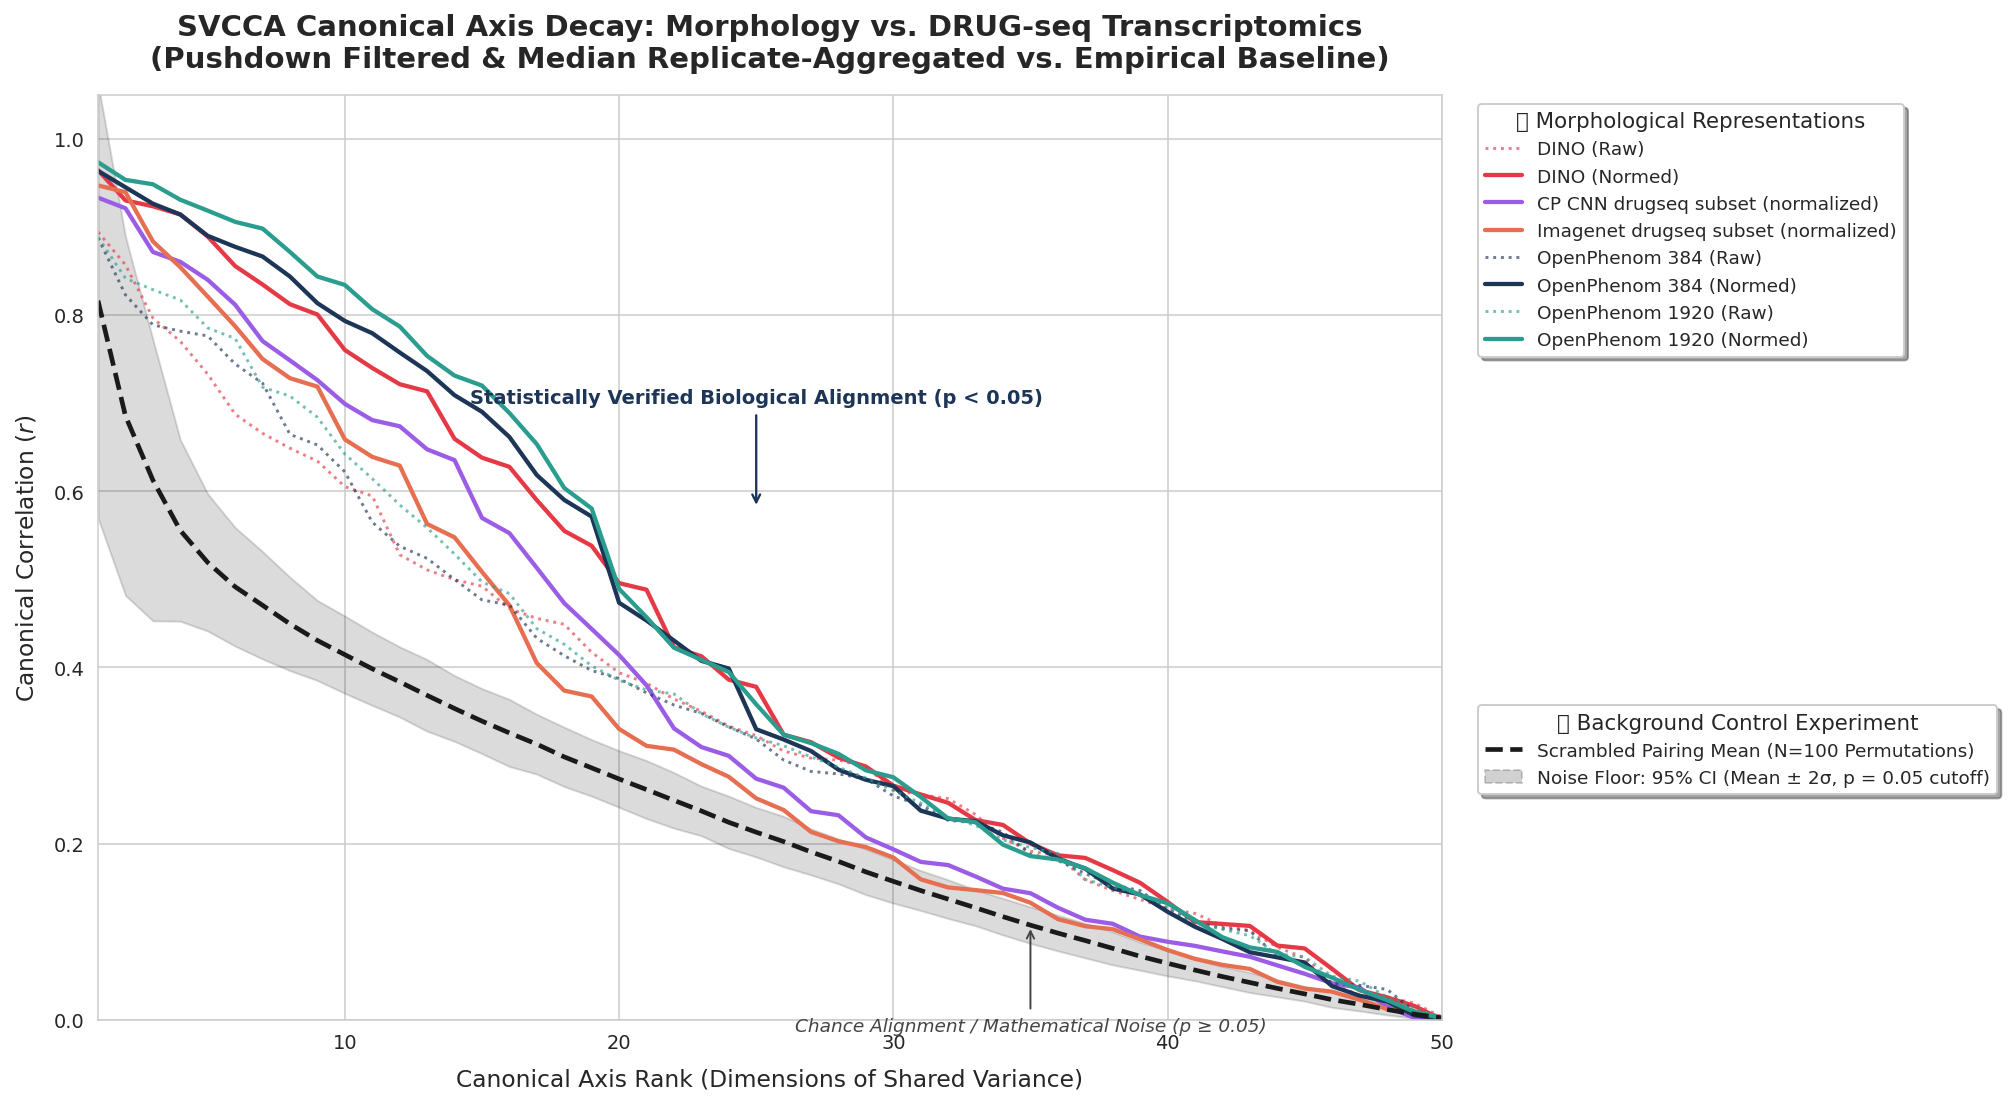

In [2]:
import os
import gc
import sys
import time
import shutil
import tempfile
import ctypes
import subprocess
import warnings
import numpy as np
import pandas as pd
import duckdb
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import torch
import psutil

warnings.filterwarnings('ignore')

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & SELF-HEALING HARDWARE SETUP
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cpu')
if torch.cuda.is_available():
    try:
        _test = torch.zeros(1, device='cuda') + 1
        device = torch.device('cuda')
        print(f"⚡ Acceleration Engine: GPU Verified ({torch.cuda.get_device_name(0)})")
    except Exception:
        print(f"⚠️ GPU detected ({torch.cuda.get_device_name(0)}), but PyTorch lacks matching kernel images.")
        print("⚡ Automatically falling back to high-throughput CPU (PyTorch MKL). Executing safely!")
        device = torch.device('cpu')
else:
    print("⚡ Running on CPU.")

# Verbose logger function with real-time RAM metrics
def log_debug(msg, t_start=None):
    ram_gb = psutil.virtual_memory().used / 1e9
    ram_pct = psutil.virtual_memory().percent
    elapsed = f"[+{time.time() - t_start:5.1f}s] " if t_start else ""
    print(f"⏱️ {elapsed}🧠 RAM: {ram_gb:4.1f}GB ({ram_pct:2.0f}%) | {msg}")

# ==============================================================================
# ⚙️ 1. CONFIGURATION: YOUR TARGET DATASETS
# ==============================================================================
MERGE_KEY = "InChIKey"
DMSO_INCHIKEY = "IAZDPXIOMUYVGZ-UHFFFAOYSA-N"

DRUGSEQ_URI = "gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/Novartis_U2OS_Dose_Time_Signatures.parquet"
LOCAL_DRUGSEQ_CACHE = "cached_drugseq_24_48h.parquet"

# 🎯 YOUR EXACT TARGET DATASETS
MORPHOLOGY_DATASETS = {
   "DINO (Raw)": "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_nonorm_final.parquet",
   "DINO (Normed)": "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_normed_final.parquet",
   #"CP CNN (normalized)": "gs://calico-reference-embeddings/embeddings/CP-CNN/master_cp-cnn_normalized.parquet",
   #"Imagenet (normalized)": "gs://calico-reference-embeddings/embeddings/Imagenet/master_imagenet_normalized.parquet",
   "CP CNN drugseq subset (normalized, 512d)": "gs://calico-reference-embeddings/embeddings/CP-CNN/master_cp_cnn_512D_sphered_mad_consensus.parquet",
   "Imagenet drugseq subset (normalized)": "gs://calico-reference-embeddings/embeddings/Imagenet/master_imagenet_normed_drugseq_subset.parquet",
   "OpenPhenom 384 (Raw)": "gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384.parquet",
   "OpenPhenom 384 (Normed)": "gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_sphered_mad_robustized.parquet",
   "OpenPhenom 1920 (Raw)": "gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920.parquet",
   "OpenPhenom 1920 (Normed)": "gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_sphered_mad_robustized.parquet"
}


# ==============================================================================
# 🌩️ 2. LOAD RNA ANCHOR & DETERMINISTIC POOLING (FAST DUCKDB LOCAL PIPELINE)
# ==============================================================================
t0 = time.time()
print("\n" + "=" * 95)
log_debug("Commencing RNA Anchor Ingestion Pipeline...")
print("=" * 95)

# Reset DuckDB with a clean, isolated temporary directory
shutil.rmtree("/tmp/duckdb_temp", ignore_errors=True)
fresh_temp_dir = tempfile.mkdtemp(prefix="duckdb_clean_")

conn = duckdb.connect()
conn.execute(f"PRAGMA temp_directory='{fresh_temp_dir}';")
conn.execute("SET memory_limit = '4GB';")
conn.execute("SET preserve_insertion_order = false;")

RAW_TEMP_FILE = "raw_drugseq_temp.parquet"

# Step 2A: Check local cache vs Fast Binary Download
if not os.path.exists(LOCAL_DRUGSEQ_CACHE) or os.path.getsize(LOCAL_DRUGSEQ_CACHE) == 0:
    log_debug("Local cache not found. Downloading raw binary directly from GCS...", t0)
    t_dl = time.time()

    # Direct binary copy bypasses the 15,000-column HTTP request bottleneck
    cmd = ["gcloud", "storage", "cp", DRUGSEQ_URI, RAW_TEMP_FILE]
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        log_debug(f"❌ Download failed: {res.stderr}", t0)
        raise RuntimeError(f"Could not download {DRUGSEQ_URI}")

    raw_size_mb = os.path.getsize(RAW_TEMP_FILE) / 1e6
    log_debug(f"✅ Raw binary downloaded: {raw_size_mb:.1f} MB in {time.time() - t_dl:.1f}s", t0)

    # Step 2B: Local DuckDB Pushdown (24H/48H Filter)
    log_debug("Filtering strictly to 24H and 48H timepoints locally on SSD...", t0)
    t_filter = time.time()

    con_filter = duckdb.connect()
    raw_total_rows = con_filter.execute(f"SELECT COUNT(*) FROM read_parquet('{RAW_TEMP_FILE}')").fetchone()[0]
    log_debug(f"Total raw signatures in file: {raw_total_rows:,} rows", t0)

    filter_query = f"""
        SELECT *
        FROM read_parquet('{RAW_TEMP_FILE}')
        WHERE CAST(pert_time_h AS FLOAT) IN (24, 48)
    """
    con_filter.execute(f"COPY ({filter_query}) TO '{LOCAL_DRUGSEQ_CACHE}' (FORMAT PARQUET, COMPRESSION 'SNAPPY')")
    con_filter.close()

    if os.path.exists(RAW_TEMP_FILE):
        os.remove(RAW_TEMP_FILE)

    filtered_size_mb = os.path.getsize(LOCAL_DRUGSEQ_CACHE) / 1e6
    log_debug(f"✅ Filter complete in {time.time() - t_filter:.1f}s. Saved: {LOCAL_DRUGSEQ_CACHE} ({filtered_size_mb:.1f} MB)", t0)
else:
    cached_size_mb = os.path.getsize(LOCAL_DRUGSEQ_CACHE) / 1e6
    log_debug(f"✅ Found existing local cache: {LOCAL_DRUGSEQ_CACHE} ({cached_size_mb:.1f} MB)", t0)

# Step 2C: Load and Prepare DRUG-seq
log_debug("Loading filtered dataset into Pandas...", t0)
t_load = time.time()
drugseq_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_DRUGSEQ_CACHE}')").df()
log_debug(f"Loaded {len(drugseq_df):,} rows into memory in {time.time() - t_load:.1f}s", t0)

for col in drugseq_df.columns:
    if 'inchikey' in col.lower():
        drugseq_df = drugseq_df.rename(columns={col: MERGE_KEY})
        break

drugseq_features = [c for c in drugseq_df.select_dtypes(include=[np.number]).columns
                    if c not in [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']]
log_debug(f"Identified {len(drugseq_features):,} numerical gene expression features.", t0)

# Step 2D: Deterministic Max-Absolute Pooling
log_debug("Applying Deterministic Max-Absolute Pooling across replicates/doses...", t0)
t_pool = time.time()

sort_cols = [c for c in [MERGE_KEY, 'pert_dose_uM', 'pert_time_h'] if c in drugseq_df.columns]
drugseq_df = drugseq_df.sort_values(by=sort_cols, kind='stable').reset_index(drop=True)

grouped = drugseq_df.groupby(MERGE_KEY, sort=True)[drugseq_features]
def pool_func(x):
    idx = np.argmax(np.abs(x.values), axis=0)
    return x.values[idx, np.arange(x.shape[1])]

drugseq_pooled = pd.DataFrame(grouped.apply(pool_func).tolist(),
                              index=grouped.apply(pool_func).index,
                              columns=drugseq_features).reset_index()

# Filter out DMSO to avoid null blob inflation
drugseq_pooled = drugseq_pooled[drugseq_pooled[MERGE_KEY] != DMSO_INCHIKEY]
drugseq_pooled = drugseq_pooled.sort_values(by=MERGE_KEY, kind='stable').reset_index(drop=True)

del drugseq_df
gc.collect()

log_debug(f"✅ Pooling complete in {time.time() - t_pool:.1f}s!", t0)
log_debug(f"Final DRUG-seq Matrix: {len(drugseq_pooled):,} unique compounds x {len(drugseq_features):,} genes", t0)

# Register in DuckDB for downstream pushdown queries
conn.register("drugseq_pooled_view", drugseq_pooled)
log_debug("Registered 'drugseq_pooled_view' in DuckDB. RNA Anchor is ready.", t0)
print("=" * 95 + "\n")

# ==============================================================================
# ⚡ 3. EXACT CLOSED-FORM LINEAR ALGEBRA
# ==============================================================================
def svd_flip_torch(u, v):
    max_abs_cols = torch.argmax(torch.abs(u), dim=0)
    signs = torch.sign(u[max_abs_cols, range(u.shape[1])])
    signs[signs == 0] = 1.0
    u = u * signs
    v = v * signs.unsqueeze(1)
    return u, v

def get_exact_subspace_basis(M, k):
    G = torch.matmul(M, M.T)
    eigvals, eigvecs = torch.linalg.eigh(G)
    idx = torch.argsort(eigvals, descending=True)[:k]
    U_k = eigvecs[:, idx]
    max_idx = torch.argmax(torch.abs(U_k), dim=0)
    col_signs = torch.sign(U_k[max_idx, range(k)])
    col_signs[col_signs == 0] = 1.0
    return U_k * col_signs

def evaluate_alignment_exact(X_np, Y_np, n_permutations=100, seed=42):
    X = torch.tensor(X_np, device=device, dtype=torch.float64)
    Y = torch.tensor(Y_np, device=device, dtype=torch.float64)
    N = X.shape[0]

    X = X - X.mean(dim=0)
    Y = Y - Y.mean(dim=0)

    K = torch.matmul(X, X.T)
    L = torch.matmul(Y, Y.T)

    norm_x = torch.sqrt(torch.sum(K * K))
    norm_y = torch.sqrt(torch.sum(L * L))
    denom = (norm_x * norm_y) + 1e-12

    true_cka = (torch.sum(K * L) / denom).item()

    gen = torch.Generator(device=device).manual_seed(seed)
    null_ckas = []

    for _ in range(n_permutations):
        idx = torch.randperm(N, generator=gen, device=device)
        L_perm = L[idx][:, idx]
        null_ckas.append((torch.sum(K * L_perm) / denom).item())

    null_ckas = np.array(null_ckas)
    null_mean = np.mean(null_ckas)
    adj_sig = true_cka - null_mean
    p_val = (np.sum(null_ckas >= true_cka) + 1) / (n_permutations + 1)

    return true_cka, null_mean, adj_sig, p_val

def get_svcca_decay_exact(X_np, Y_np, k_dims=50):
    X = torch.tensor(X_np, device=device, dtype=torch.float64)
    Y = torch.tensor(Y_np, device=device, dtype=torch.float64)
    N = X.shape[0]
    max_k = min(int(N * 0.8), X.shape[1], Y.shape[1], k_dims)

    X = X - X.mean(dim=0)
    Y = Y - Y.mean(dim=0)

    Qa = get_exact_subspace_basis(X, max_k)
    Qb = get_exact_subspace_basis(Y, max_k)

    cross_cov = torch.matmul(Qa.T, Qb)
    U, S, Vt = torch.linalg.svd(cross_cov)
    U, _ = svd_flip_torch(U, Vt)

    return torch.sort(S, descending=True)[0].cpu().numpy()

# ==============================================================================
# 🏆 4. THE BENCHMARK LOOP ACROSS YOUR TARGET MODELS
# ==============================================================================
results_leaderboard = []
decay_curves = {}

print("=" * 95)
print("🚀 COMMENCING REPLICATE-AGGREGATED MORPHOLOGY BENCHMARK")
print("=" * 95)

for name, uri in MORPHOLOGY_DATASETS.items():
    clean_tag = name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '').replace('-', '_')
    cache_name = f"cached_{clean_tag}.parquet"

    # Check local file size to remove 0-byte stubs
    if os.path.exists(cache_name) and os.path.getsize(cache_name) == 0:
        os.remove(cache_name)

    # 💡 Direct binary download via gcloud storage
    if not os.path.exists(cache_name):
        print(f"\n📥 Downloading {name} from GCS ({uri})...")
        cmd = ["gcloud", "storage", "cp", uri, cache_name]
        res = subprocess.run(cmd, capture_output=True, text=True)
        if res.returncode != 0:
            print(f"  ❌ Failed to download {name}: {res.stderr}")
            if os.path.exists(cache_name):
                os.remove(cache_name)
            continue
        print(f"  ✅ Cached {cache_name} ({os.path.getsize(cache_name)/1e6:.1f} MB)")

    # Read schema safely
    try:
        schema_fields = [f.name for f in pq.read_schema(cache_name)]
    except Exception as e:
        print(f"  ❌ [CORRUPT FILE] Could not read schema for {name}: {e}. Skipping.")
        continue

    ikey_col = next((c for c in schema_fields if 'inchikey' in c.lower()), None)
    if not ikey_col:
        print(f"  ❌ No InChIKey found in {name}. Skipping.")
        continue

    has_pert_type = 'Metadata_pert_type' in schema_fields
    pert_filter = "AND m.Metadata_pert_type = 'trt'" if has_pert_type else ""

    # 💡 THE MEMORY FIX: Single-threaded read limits in-flight row-group decompression
    conn.execute("SET threads = 1;")
    conn.execute("SET preserve_insertion_order = false;")

    pushdown_query = f"""
        SELECT *
        FROM read_parquet('{cache_name}') m
        WHERE {ikey_col} IN (SELECT DISTINCT {MERGE_KEY} FROM drugseq_pooled_view)
        {pert_filter}
    """
    try:
        morph_df = conn.execute(pushdown_query).df()
    except Exception as e:
        print(f"  ❌ Failed to query {name}: {e}. Skipping.")
        continue
    finally:
        conn.execute("SET threads = 4;")

    if ikey_col != MERGE_KEY:
        morph_df = morph_df.rename(columns={ikey_col: MERGE_KEY})

    if morph_df.empty:
        print(f"  ❌ Zero overlapping compounds with DRUG-seq for {name}. Skipping.")
        del morph_df
        gc.collect()
        continue

    # Grouping columns for replicate median aggregation
    group_cols = [MERGE_KEY]
    for candidates in [
        ['concentration', 'Metadata_Concentration', 'pert_dose', 'pert_dose_uM', 'dose'],
        ['Metadata_Time', 'pert_time', 'pert_time_h', 'time', 'timepoint'],
        ['Metadata_cell_line', 'Metadata_CellLine', 'Metadata_cell_type', 'cell_line', 'cell_type']
    ]:
        for c in candidates:
            if c in morph_df.columns and c not in group_cols:
                group_cols.append(c)
                break

    morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns
                      if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid'] + group_cols]

    if len(morph_features) == 0:
        print(f"  ❌ No numeric features found in {name}. Skipping.")
        del morph_df
        gc.collect()
        continue

    # Fast median replicate aggregation on pre-filtered rows (< 200 MB RAM!)
    raw_wells = len(morph_df)
    morph_df = morph_df.groupby(group_cols, as_index=False, dropna=False)[morph_features].median()
    morph_df = morph_df.sort_values(by=group_cols, kind='stable').reset_index(drop=True)
    agg_profiles = len(morph_df)

    aligned_df = pd.merge(morph_df, drugseq_pooled, on=MERGE_KEY, how="inner")
    aligned_df = aligned_df.sort_values(by=group_cols, kind='stable').reset_index(drop=True)
    overlap_N = len(aligned_df)

    X_morph = np.nan_to_num(aligned_df[morph_features].values.astype(np.float32))
    Y_rna = np.nan_to_num(aligned_df[drugseq_features].values.astype(np.float32))

    # Evaluate
    true_cka, null_cka, adj_sig, p_val = evaluate_alignment_exact(X_morph, Y_rna, n_permutations=100)
    corrs = get_svcca_decay_exact(X_morph, Y_rna, k_dims=50)
    decay_curves[name] = corrs

    svcca_mean_auc = float(np.mean(corrs))
    axes_above_50 = int(np.sum(corrs >= 0.50))

    print(f"[{name:<32}] Filtered: {raw_wells:5d} ➔ {agg_profiles:4d} | AUC: {svcca_mean_auc:.4f} | Axes r>=0.5: {axes_above_50:2d} | CKA: {adj_sig:+.4f}")

    results_leaderboard.append({
        "Model / Processing": name,
        "Overlap (N)": overlap_N,
        "Dimensions": len(morph_features),
        "SVCCA Mean (AUC)": svcca_mean_auc,
        "Axes r >= 0.50": axes_above_50,
        "CKA Adj. Signal": adj_sig,
        "Adj. Signal (Score)": adj_sig,
        "True CKA": true_cka,
        "Null Baseline": null_cka,
        "P-Value": p_val
    })

    # Force glibc memory release
    del morph_df, aligned_df, X_morph, Y_rna
    gc.collect()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass

# ==============================================================================
# 📈 5. FINAL LEADERBOARD
# ==============================================================================
leaderboard_df = pd.DataFrame(results_leaderboard)
leaderboard_df = leaderboard_df.sort_values(by="SVCCA Mean (AUC)", ascending=False, kind='stable').reset_index(drop=True)

print("\n" + "="*115)
print("🏆 FINAL BENCHMARK LEADERBOARD (Ranked by Shallow Decay: SVCCA Mean AUC)")
print("="*115)
print(leaderboard_df.to_string(index=True, float_format="{:.4f}".format))
print("="*115)

# ==============================================================================
# 🎲 6. EMPIRICAL PERMUTATION BASELINE (100 GPU PERMUTATIONS ON WINNER)
# ==============================================================================
top_winner_name = leaderboard_df.iloc[0]["Model / Processing"]
winner_clean_tag = top_winner_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '').replace('-', '_')
winner_file = f"cached_{winner_clean_tag}.parquet"

print(f"\nComputing Empirical SVCCA Null Baseline on winning model: [{top_winner_name}] (100 Permutations)...")

schema_fields = [f.name for f in pq.read_schema(winner_file)]
ikey_col = next((c for c in schema_fields if 'inchikey' in c.lower()), None)
has_pert_type = 'Metadata_pert_type' in schema_fields
pert_filter = "AND m.Metadata_pert_type = 'trt'" if has_pert_type else ""

conn.execute("SET threads = 1;")
pushdown_query = f"""
    SELECT *
    FROM read_parquet('{winner_file}') m
    WHERE {ikey_col} IN (SELECT DISTINCT {MERGE_KEY} FROM drugseq_pooled_view)
    {pert_filter}
"""
winner_df = conn.execute(pushdown_query).df()
conn.close()

if ikey_col != MERGE_KEY:
    winner_df = winner_df.rename(columns={ikey_col: MERGE_KEY})

w_group_cols = [MERGE_KEY]
for candidates in [
    ['concentration', 'Metadata_Concentration', 'pert_dose', 'pert_dose_uM', 'dose'],
    ['Metadata_Time', 'pert_time', 'pert_time_h', 'time', 'timepoint'],
    ['Metadata_cell_line', 'Metadata_CellLine', 'Metadata_cell_type', 'cell_line', 'cell_type']
]:
    for c in candidates:
        if c in winner_df.columns and c not in w_group_cols:
            w_group_cols.append(c)
            break

w_features = [c for c in winner_df.select_dtypes(include=[np.number]).columns
              if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid'] + w_group_cols]

winner_df = winner_df.groupby(w_group_cols, as_index=False, dropna=False)[w_features].median()
w_aligned = pd.merge(winner_df, drugseq_pooled, on=MERGE_KEY, how="inner").sort_values(by=w_group_cols, kind='stable').reset_index(drop=True)

X_win = torch.tensor(np.nan_to_num(w_aligned[w_features].values.astype(np.float64)), device=device)
Y_win = torch.tensor(np.nan_to_num(w_aligned[drugseq_features].values.astype(np.float64)), device=device)
N_win = X_win.shape[0]
k_dims = 50
max_k = min(int(N_win * 0.8), X_win.shape[1], Y_win.shape[1], k_dims)

X_win = X_win - X_win.mean(dim=0)
Y_win = Y_win - Y_win.mean(dim=0)

Qa_win = get_exact_subspace_basis(X_win, max_k)

gen = torch.Generator(device=device).manual_seed(SEED)
null_corrs_list = []

for _ in range(100):
    idx = torch.randperm(N_win, generator=gen, device=device)
    Y_shuf = Y_win[idx]
    Qb_shuf = get_exact_subspace_basis(Y_shuf, max_k)
    cross_cov = torch.matmul(Qa_win.T, Qb_shuf)
    _, S_null, _ = torch.linalg.svd(cross_cov)
    null_corrs_list.append(torch.sort(S_null, descending=True)[0].cpu().numpy())

null_matrix = np.array(null_corrs_list)
null_mean = null_matrix.mean(axis=0)
null_std = null_matrix.std(axis=0)

del winner_df, w_aligned, X_win, Y_win, Qa_win
gc.collect()

# ==============================================================================
# 📊 7. PUBLICATION-READY SVCCA AXIS DECAY PLOT (DUAL STRUCTURED LEGENDS)
# ==============================================================================
print("Generating SVCCA Axis Decay Plot with Enhanced Control Legends...")
fig, ax = plt.subplots(figsize=(14.5, 8), dpi=140)
sns.set_style("whitegrid")

color_map = {
    "DINO": "#E63946",             # Red
    "OpenPhenom 384": "#1D3557",     # Navy
    "OpenPhenom 1920": "#2A9D8F",    # Teal
    "CP CNN": "#9B5DE5",             # Purple
    "Imagenet": "#E76F51"            # Coral
}

model_lines = []

for name, corrs in decay_curves.items():
    c = next((col for k, col in color_map.items() if name.startswith(k)), "gray")
    ls = ":" if "Raw" in name else "-"
    lw = 2.2 if ("Normed" in name or "normalized" in name) else 1.5
    alpha = 1.0 if ("Normed" in name or "normalized" in name) else 0.65

    line, = ax.plot(range(1, len(corrs) + 1), corrs,
                    label=name, color=c, linestyle=ls, linewidth=lw, alpha=alpha)
    model_lines.append(line)

# Empirical Permutation Baseline & Noise Floor
x_axes = range(1, len(null_mean) + 1)
null_line, = ax.plot(x_axes, null_mean, color='#1A1A1A', linestyle='--', linewidth=2.4,
                     label='Scrambled Pairing Mean (N=100 Permutations)')

noise_band = ax.fill_between(x_axes, null_mean - (2 * null_std), null_mean + (2 * null_std),
                             color='black', alpha=0.14,
                             label='Noise Floor: 95% CI (Mean ± 2σ, p = 0.05 cutoff)')

# Contextual Callout Annotations
ax.annotate('Statistically Verified Biological Alignment (p < 0.05)',
            xy=(25, 0.58), xytext=(25, 0.70),
            ha='center', fontsize=10, fontweight='bold', color='#1D3557',
            arrowprops=dict(arrowstyle='->', color='#1D3557', lw=1.2))

ax.annotate('Chance Alignment / Mathematical Noise (p ≥ 0.05)',
            xy=(35, null_mean[34]), xytext=(35, null_mean[34] - 0.12),
            ha='center', fontsize=9.5, fontstyle='italic', color='#444444',
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.0))

# Structured Dual Legends
legend_models = ax.legend(
    handles=model_lines,
    title="🧬 Morphological Representations",
    bbox_to_anchor=(1.02, 1.0),
    loc='upper left',
    fontsize=9.5,
    title_fontsize=11,
    frameon=True,
    shadow=True
)
ax.add_artist(legend_models)

control_handles = [
    Line2D([0], [0], color='#1A1A1A', linestyle='--', linewidth=2.4,
           label='Scrambled Pairing Mean (N=100 Permutations)'),
    Patch(facecolor='black', alpha=0.18, edgecolor='black', linestyle='--',
          label='Noise Floor: 95% CI (Mean ± 2σ, p = 0.05 cutoff)')
]

legend_controls = ax.legend(
    handles=control_handles,
    title="🎲 Background Control Experiment",
    bbox_to_anchor=(1.02, 0.35),
    loc='upper left',
    fontsize=9.5,
    title_fontsize=11,
    frameon=True,
    shadow=True
)

ax.set_title('SVCCA Canonical Axis Decay: Morphology vs. DRUG-seq Transcriptomics\n'
             '(Pushdown Filtered & Median Replicate-Aggregated vs. Empirical Baseline)',
             fontsize=15, pad=14, fontweight='bold')
ax.set_xlabel('Canonical Axis Rank (Dimensions of Shared Variance)', fontsize=12, labelpad=8)
ax.set_ylabel('Canonical Correlation ($r$)', fontsize=12, labelpad=8)
ax.set_xlim(1, 50)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [ ]:
import os
import urllib.request
import duckdb
from tqdm import tqdm

METADATA_DUCKDB_URL = "https://github.com/jump-cellpainting/datasets/releases/download/v0.13/jump_metadata.duckdb"
LOCAL_METADATA_DB = "jump_metadata.duckdb"

# Progress bar hook for urllib
class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

print("=" * 80)
print(f"📥 DOWNLOADING JUMP METADATA DATABASE (~169 MB)")
print(f"   URL: {METADATA_DUCKDB_URL}")
print("=" * 80)

# Stream and save to disk
if not os.path.exists(LOCAL_METADATA_DB):
    with DownloadProgressBar(unit='B', unit_scale=True, miniters=1, desc="jump_metadata.duckdb") as t:
        urllib.request.urlretrieve(METADATA_DUCKDB_URL, filename=LOCAL_METADATA_DB, reporthook=t.update_to)

file_size_mb = os.path.getsize(LOCAL_METADATA_DB) / 1e6
print(f"\n✅ Database File: {LOCAL_METADATA_DB} ({file_size_mb:.1f} MB)")

# ==============================================================================
# 🔍 VERIFY DATABASE TABLES & ROW COUNTS
# ==============================================================================
print("\nVerifying database tables...")
con = duckdb.connect()
con.execute(f"ATTACH '{LOCAL_METADATA_DB}' AS jm (READ_ONLY);")

# Fixed: Use information_schema for more robust table listing
tables = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_catalog = 'jm'
""").df()

print("📋 Tables present in jump_metadata.duckdb:")
for t_name in tables['table_name']:
    count = con.execute(f"SELECT COUNT(*) FROM jm.{t_name}").fetchone()[0]
    print(f"  ↳ {t_name:<16} : {count:,} rows")

con.close()
print("\n🎉 Database ready for plate-well and compound joins!")

📥 DOWNLOADING JUMP METADATA DATABASE (~169 MB)
   URL: https://github.com/jump-cellpainting/datasets/releases/download/v0.13/jump_metadata.duckdb

✅ Database File: jump_metadata.duckdb (176.7 MB)

Verifying database tables...
📋 Tables present in jump_metadata.duckdb:
  ↳ cellprofiler_version : 13 rows
  ↳ compound         : 115,796 rows
  ↳ compound_source  : 126,044 rows
  ↳ crispr           : 7,977 rows
  ↳ microscope_config : 13 rows
  ↳ microscope_filter : 8 rows
  ↳ orf              : 15,132 rows
  ↳ perturbation     : 138,906 rows
  ↳ perturbation_control : 18 rows
  ↳ plate            : 2,525 rows
  ↳ well             : 1,151,808 rows

🎉 Database ready for plate-well and compound joins!


In [ ]:
import duckdb
import os

# Ensure the file exists before connecting
local_db = 'jump_metadata.duckdb'
if not os.path.exists(local_db):
    raise FileNotFoundError(f'Metadata database {local_db} not found. Please run the download cell first.')

con = duckdb.connect()
# Re-attach to ensure connection sees the file
con.execute(f"ATTACH '{local_db}' AS jm (READ_ONLY);")

# Count unique chemical compounds in source_4 plates
res = con.execute("""
    SELECT
        p.Metadata_Source,
        COUNT(DISTINCT w.Metadata_Plate) AS Total_Plates,
        COUNT(DISTINCT c.Metadata_InChIKey) AS Unique_Chemical_Compounds
    FROM jm.well w
    JOIN jm.plate p ON w.Metadata_Plate = p.Metadata_Plate
    JOIN jm.compound c ON w.Metadata_JCP2022 = c.Metadata_JCP2022
    WHERE p.Metadata_Source = 'source_4'
    GROUP BY p.Metadata_Source
""").df()

con.close()
print(res)

  Metadata_Source  Total_Plates  Unique_Chemical_Compounds
0        source_4           277                        303


# Interpret each correlated axis using Chem Checker and GSEA

# Compare chemical checker vs. each correlated axis

⚡ Acceleration Engine: GPU Verified (Tesla V100-SXM2-16GB)
🏆 DECODING WINNING MODEL: [OpenPhenom 1920 (Normed)] (SVCCA Mean AUC: 0.4369)
🔬 Target Space: Chemical Checker 3,200D Bioactivity Signatures
🎯 Decoding Horizon: Top 10 Biological Axes
📂 Loading winner morphology from: cached_OpenPhenom_1920_Normed.parquet...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ↳ Consolidated 76725 morphology wells into 9946 median treatment profiles.
Filtering silent genes to isolate the dynamic transcriptome...
  ↳ Retained Top 5000 highly variable genes (discarded flat baseline noise).


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Chemical Checker ready: 115689 unique molecules with 3200 dimensions.


INFO:biothings.client:querying 1-1000 ...


✅ Projection Complete: 523 consensus treatments projected onto 10 axes.
Querying MyGene for official HGNC symbols...


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


✅ Mapped 4627 of 5000 filtered genes.

🎯 Bio_Axis_1 | Canonical Correlation ($r$): 0.9420
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : TMEM37 (+0.44), MIR210HG (+0.38), FOXO6 (+0.38), WFDC21P (+0.36), ENSG00000248751 (+0.33)
  ↳ Key Downregulated : ZNF571 (-0.43), PPP1R15A (-0.41), CXCL8 (-0.40), ENSG00000273416 (-0.40), FOS (-0.40)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • E2F Targets                                      | NES: +1.47 | FDR: 4.88e-01
     • Myogenesis                                       | NES: +1.43 | FDR: 3.36e-01
     • Interferon Alpha Response                        | NES: +1.38 | FDR: 3.07e-01
     • KRAS Signaling Dn                                | NES: +1.34 | FDR: 2.97e-01
     • Wnt-beta Catenin Signaling                       | NES: +1.25 | FDR: 3.80e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -2.75 | FDR: 0.00e+00
     • Epithelial Mesenchymal Transition             

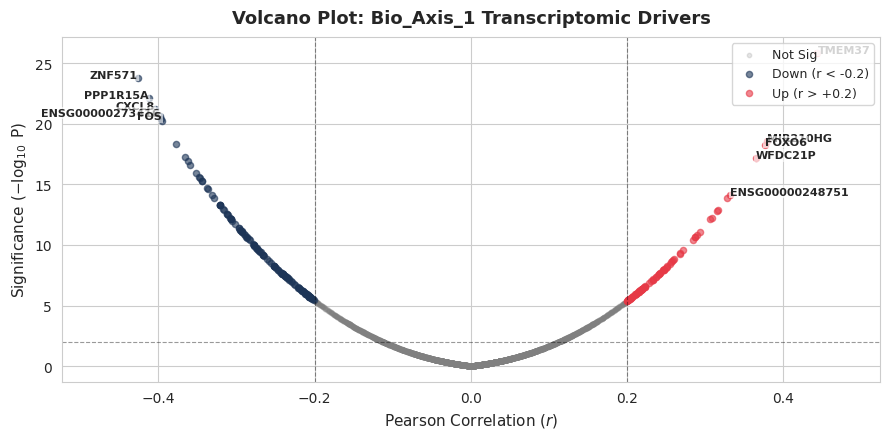


🎯 Bio_Axis_2 | Canonical Correlation ($r$): 0.9139
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : DDIT3 (+0.49), MAFF (+0.41), HMOX1 (+0.40), RDUR (+0.39), GDF15 (+0.38)
  ↳ Key Downregulated : PDLIM1 (-0.56), EDN2 (-0.56), TNNT2 (-0.50), PSLNR (-0.47), KRT75 (-0.45)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: +2.53 | FDR: 0.00e+00
     • Apoptosis                                        | NES: +2.26 | FDR: 0.00e+00
     • p53 Pathway                                      | NES: +2.13 | FDR: 0.00e+00
     • UV Response Up                                   | NES: +2.06 | FDR: 0.00e+00
     • Hypoxia                                          | NES: +1.86 | FDR: 5.01e-03

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • E2F Targets                                      | NES: -1.83 | FDR: 7.98e-03
     • Myogenesis                                       | NES: -1.71 | FDR: 2.66e-02
     • G2-M Checkpoint              

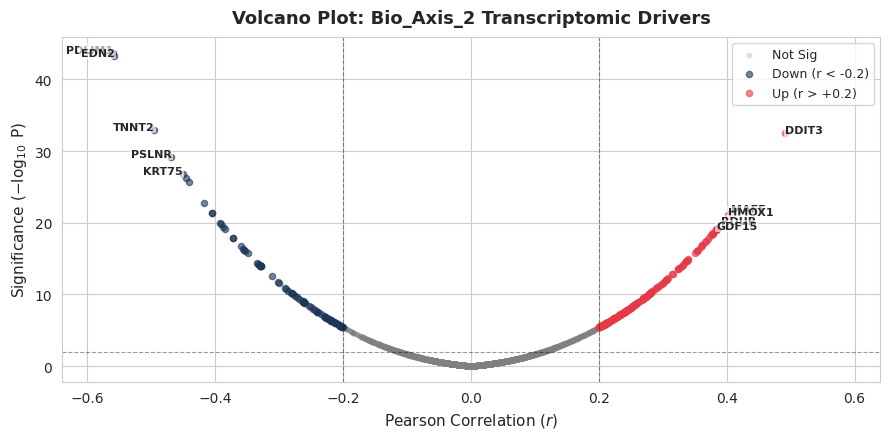


🎯 Bio_Axis_3 | Canonical Correlation ($r$): 0.9059
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : DYNLT4 (+0.30), LCP1 (+0.28), IL6R (+0.26), GCNT2 (+0.25), OSTM1 (+0.25)
  ↳ Key Downregulated : IRGM (-0.53), MIR7-3HG (-0.48), GAST (-0.48), HBA2 (-0.45), HBA1 (-0.43)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Unfolded Protein Response                        | NES: +1.35 | FDR: 3.83e-01
     • TGF-beta Signaling                               | NES: +0.93 | FDR: 1.00e+00
     • Spermatogenesis                                  | NES: +0.91 | FDR: 9.97e-01
     • G2-M Checkpoint                                  | NES: +0.80 | FDR: 1.00e+00
     • E2F Targets                                      | NES: +0.63 | FDR: 9.57e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Estrogen Response Late                           | NES: -1.88 | FDR: 0.00e+00
     • Interferon Alpha Response                        | NES: -1.50 | FDR: 3.49e-01
     • p53 Pathway                  

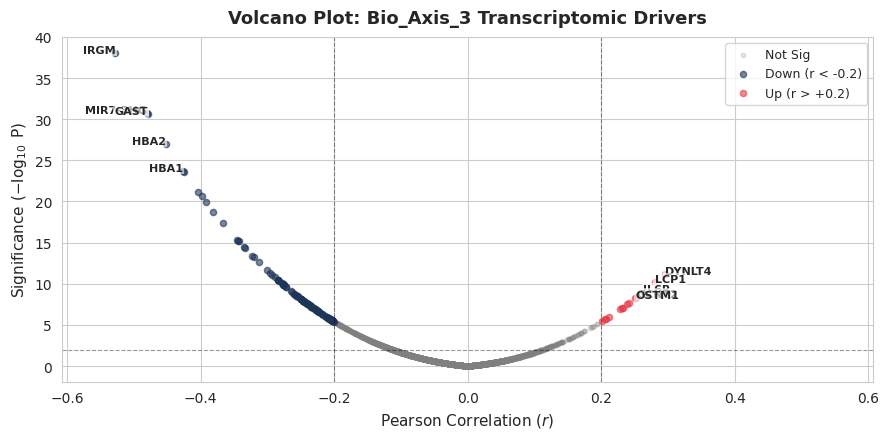


🎯 Bio_Axis_4 | Canonical Correlation ($r$): 0.8566
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : RAB7B (+0.24), EDN2 (+0.21), PDLIM1 (+0.19), WFDC21P (+0.18), KRT75 (+0.18)
  ↳ Key Downregulated : RPL13AP19 (-0.38), GABRG3 (-0.37), TMEM117 (-0.37), ENPP2 (-0.35), LOC124904601 (-0.35)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • E2F Targets                                      | NES: +2.19 | FDR: 0.00e+00
     • G2-M Checkpoint                                  | NES: +1.24 | FDR: 1.63e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -1.71 | FDR: 1.50e-02
     • Apoptosis                                        | NES: -1.65 | FDR: 2.99e-02
     • Epithelial Mesenchymal Transition                | NES: -1.62 | FDR: 2.99e-02
     • p53 Pathway                                      | NES: -1.56 | FDR: 5.61e-02
     • IL-6/JAK/STAT3 Signaling                         | NES: -1.54 | FDR: 4.78e-02

  🔬 Direct Outlie

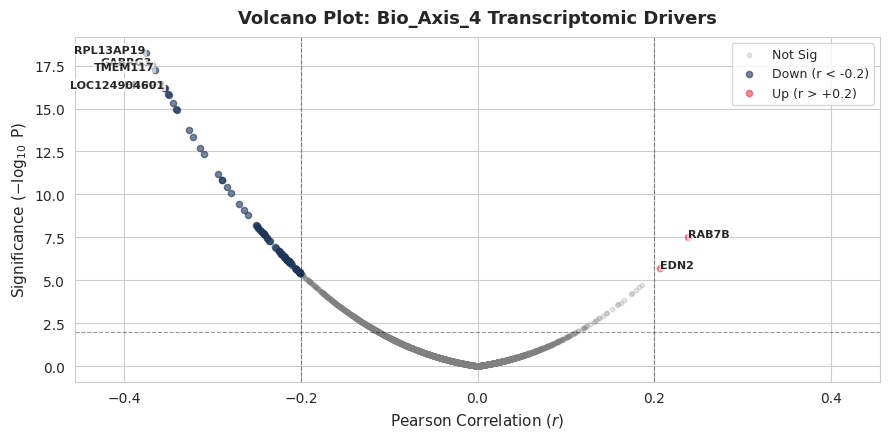


🎯 Bio_Axis_5 | Canonical Correlation ($r$): 0.8480
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : IGFL2-AS1 (+0.38), FUCA1 (+0.27), SELENOP (+0.25), HTRA1 (+0.23), SAA1 (+0.23)
  ↳ Key Downregulated : NPPB (-0.33), STRA6 (-0.31), LINC02901 (-0.30), GABRG3 (-0.30), PDLIM1 (-0.28)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Coagulation                                      | NES: +2.05 | FDR: 1.07e-02
     • p53 Pathway                                      | NES: +1.64 | FDR: 1.56e-01
     • Hypoxia                                          | NES: +1.53 | FDR: 1.86e-01
     • Apoptosis                                        | NES: +1.27 | FDR: 5.55e-01
     • TNF-alpha Signaling via NF-kB                    | NES: +1.11 | FDR: 8.97e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • E2F Targets                                      | NES: -1.89 | FDR: 3.71e-03
     • G2-M Checkpoint                                  | NES: -1.69 | FDR: 4.26e-02
     • DNA Repair       

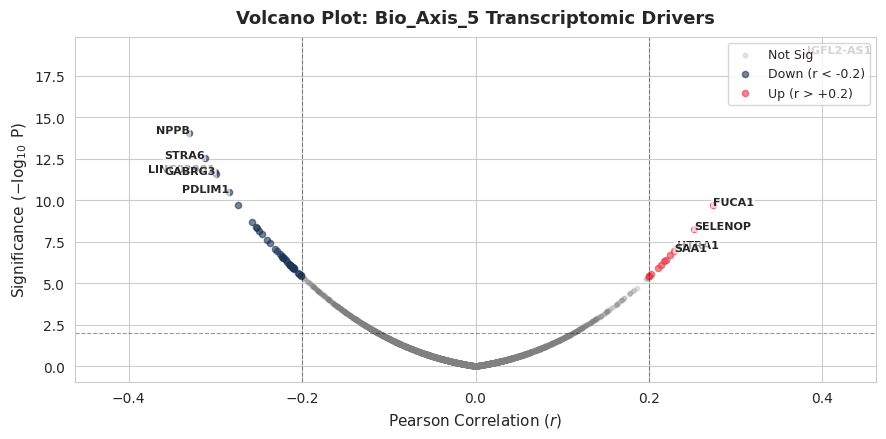


🎯 Bio_Axis_6 | Canonical Correlation ($r$): 0.8176
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : LOC101928994 (+0.30), SPRR2D (+0.27), GDF15 (+0.23), HMOX1 (+0.23), LINC00520 (+0.23)
  ↳ Key Downregulated : TSPAN2 (-0.23), RNU1-125P (-0.22), PIK3IP1 (-0.22), TXNIP (-0.21), CLIC3 (-0.20)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: +2.02 | FDR: 0.00e+00
     • IL-2/STAT5 Signaling                             | NES: +1.83 | FDR: 2.40e-02
     • mTORC1 Signaling                                 | NES: +1.64 | FDR: 9.84e-02
     • Coagulation                                      | NES: +1.64 | FDR: 7.38e-02
     • IL-6/JAK/STAT3 Signaling                         | NES: +1.57 | FDR: 1.04e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • KRAS Signaling Dn                                | NES: -1.52 | FDR: 4.39e-01
     • Bile Acid Metabolism                             | NES: -1.49 | FDR: 2.54e-01
     • Myogenes

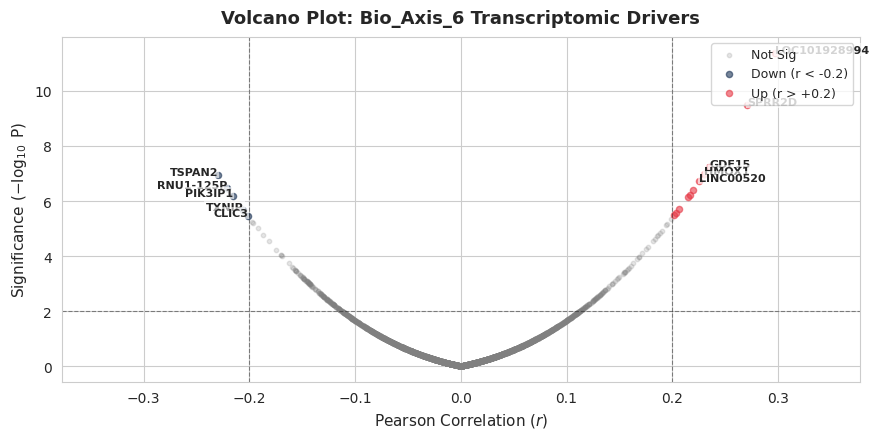


🎯 Bio_Axis_7 | Canonical Correlation ($r$): 0.7949
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : LOC101928994 (+0.33), GCNT2 (+0.22), DYNLT4 (+0.22), ATP8A2 (+0.21), MDGA1 (+0.20)
  ↳ Key Downregulated : NEURL3 (-0.28), CCDC144NL (-0.24), MBIP (-0.22), STX11 (-0.22), ALG5 (-0.21)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Coagulation                                      | NES: +1.36 | FDR: 6.29e-01
     • Xenobiotic Metabolism                            | NES: +1.28 | FDR: 4.91e-01
     • Estrogen Response Late                           | NES: +1.20 | FDR: 5.13e-01
     • KRAS Signaling Dn                                | NES: +1.10 | FDR: 6.12e-01
     • Estrogen Response Early                          | NES: +0.96 | FDR: 8.16e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • mTORC1 Signaling                                 | NES: -1.92 | FDR: 0.00e+00
     • UV Response Up                                   | NES: -1.63 | FDR: 1.20e-01
     • E2F Targets    

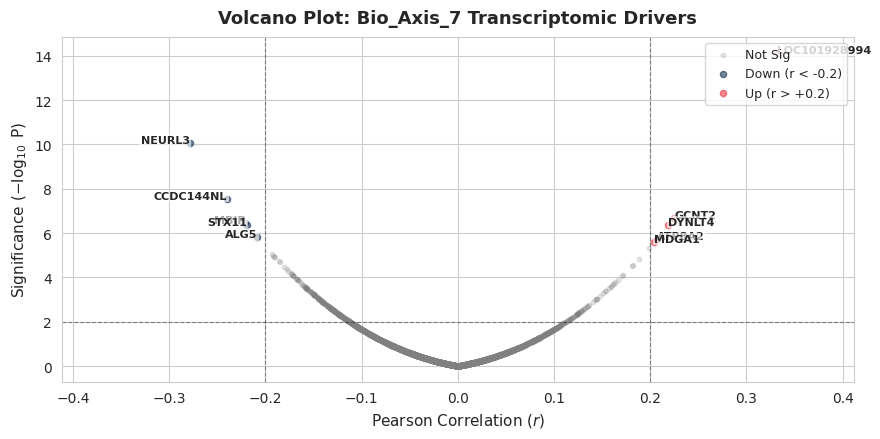


🎯 Bio_Axis_8 | Canonical Correlation ($r$): 0.7794
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : RPL9P7 (+0.20), LOC101928994 (+0.20), ATP8A2 (+0.19), TPT1P4 (+0.19), GPR27 (+0.19)
  ↳ Key Downregulated : INSL4 (-0.26), CCL2 (-0.23), CXCL8 (-0.22), FOSB (-0.22), TBX3 (-0.22)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Mitotic Spindle                                  | NES: +1.05 | FDR: 1.00e+00
     • E2F Targets                                      | NES: +0.79 | FDR: 1.00e+00
     • Spermatogenesis                                  | NES: +0.72 | FDR: 1.00e+00
     • Angiogenesis                                     | NES: +0.68 | FDR: 9.29e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -2.76 | FDR: 0.00e+00
     • Allograft Rejection                              | NES: -1.99 | FDR: 6.64e-03
     • p53 Pathway                                      | NES: -1.90 | FDR: 8.85e-03
     • Unfolded Protein Res

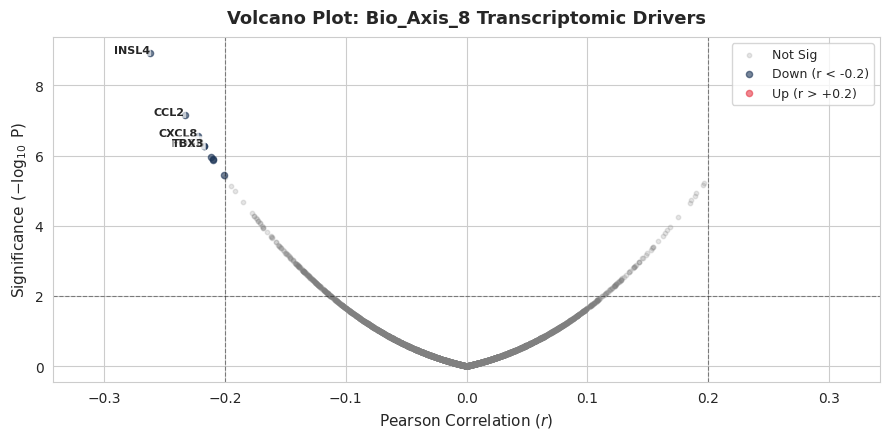


🎯 Bio_Axis_9 | Canonical Correlation ($r$): 0.7552
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : KRT34 (+0.26), KRTAP2-3 (+0.20), MAP3K8 (+0.20), AFG2A (+0.19), ENSG00000231903 (+0.19)
  ↳ Key Downregulated : RPS2P32 (-0.25), GCNA (-0.24), LIMS3 (-0.23), ICAM1 (-0.23), ZFX (-0.22)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Epithelial Mesenchymal Transition                | NES: +2.13 | FDR: 1.01e-02
     • Cholesterol Homeostasis                          | NES: +1.83 | FDR: 7.61e-02
     • mTORC1 Signaling                                 | NES: +1.72 | FDR: 9.81e-02
     • Androgen Response                                | NES: +1.64 | FDR: 1.24e-01
     • TNF-alpha Signaling via NF-kB                    | NES: +1.63 | FDR: 1.08e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • KRAS Signaling Up                                | NES: -1.52 | FDR: 4.32e-01
     • Complement                                       | NES: -1.30 | FDR: 9.32e-01
     • E2F Targets   

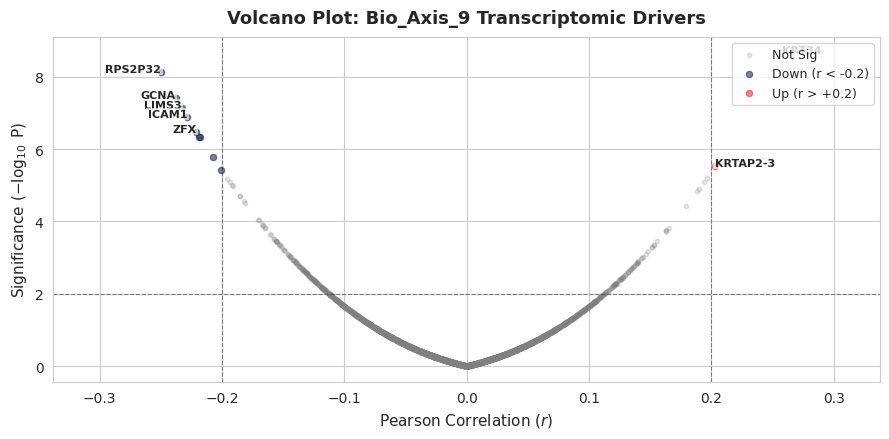


🎯 Bio_Axis_10 | Canonical Correlation ($r$): 0.7420
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : HAMP (+0.56), CACNG6 (+0.46), ENSG00000285646 (+0.46), MIXL1 (+0.45), PRRT3-AS1 (+0.45)
  ↳ Key Downregulated : KRT34 (-0.18), ROBO4 (-0.15), STING1 (-0.13), ULK3 (-0.12), IL11 (-0.12)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Estrogen Response Late                           | NES: +1.49 | FDR: 3.53e-01
     • Unfolded Protein Response                        | NES: +1.40 | FDR: 5.97e-01
     • Xenobiotic Metabolism                            | NES: +1.35 | FDR: 6.76e-01
     • Fatty Acid Metabolism                            | NES: +1.33 | FDR: 6.22e-01
     • UV Response Up                                   | NES: +1.32 | FDR: 5.29e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Coagulation                                      | NES: -0.84 | FDR: 1.00e+00
     • PI3K/AKT/mTOR  Signaling                         | NES: -0.76 | FDR: 9.12e-01

  🔬 Direct Outlier 

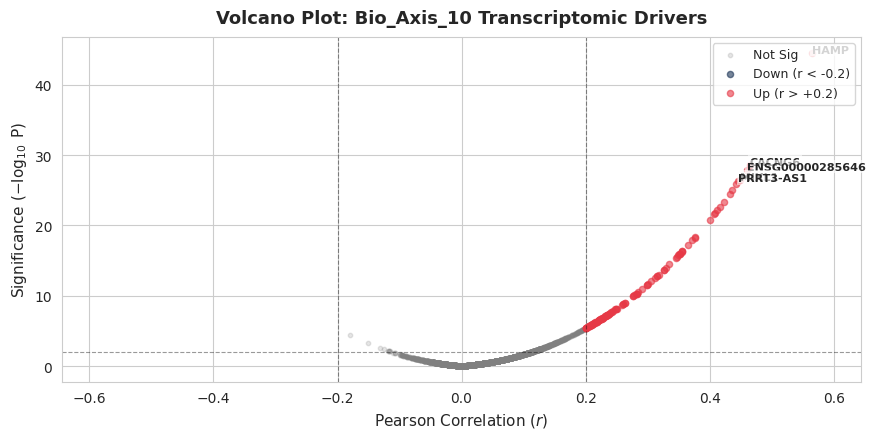


🏁 ENHANCED BIOLOGICAL & CHEMICAL DECODING COMPLETE


In [ ]:
import os
import gc
import re
import warnings
import requests
from collections import Counter
import numpy as np
import pandas as pd
import duckdb
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import mannwhitneyu, t as t_dist

# Auto-install bioinformatics packages if missing
for pkg in ['mygene', 'gseapy']:
    try:
        __import__(pkg)
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import mygene
import gseapy as gp

warnings.filterwarnings('ignore')

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & SELF-HEALING HARDWARE SETUP
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cpu')
if torch.cuda.is_available():
    try:
        _test = torch.zeros(1, device='cuda') + 1
        device = torch.device('cuda')
        print(f"⚡ Acceleration Engine: GPU Verified ({torch.cuda.get_device_name(0)})")
    except Exception:
        print(f"⚠️ GPU detected ({torch.cuda.get_device_name(0)}), but PyTorch lacks matching kernel images.")
        print("⚡ Automatically falling back to high-throughput CPU (PyTorch MKL). Executing safely!")
        device = torch.device('cpu')
else:
    print("⚡ Running on CPU.")

# ==============================================================================
# 🌐 1. UPGRADED 3-TIER ANNOTATION ENGINE (PubChem + ChEMBL Block-1 Rescue)
# ==============================================================================
ANNOTATION_CACHE = {}

def get_rich_compound_annotation(inchikey):
    """
    3-Tier Annotation Engine:
    1. PubChem Synonyms (captures research codes & generic names)
    2. ChEMBL with Part II Block-1 Rescue (startswith[:14])
    3. ChEMBL IC50 Potency Targets (< 500nM) for non-clinical tool compounds
    """
    if inchikey in ANNOTATION_CACHE:
        return ANNOTATION_CACHE[inchikey]

    name = "Unknown"
    moa = "Unannotated"
    cid = None

    # --- TIER 1: PubChem Synonyms ---
    try:
        url_syn = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{inchikey}/synonyms/JSON"
        r = requests.get(url_syn, timeout=4)
        if r.status_code == 200:
            info = r.json().get('InformationList', {}).get('Information', [{}])[0]
            cid = info.get('CID')
            synonyms = info.get('Synonym', [])

            for s in synonyms[:15]:
                if not re.match(r'^\d+-\d+-\d+$', s) and len(s) > 2:
                    if not any(s.startswith(prefix) for prefix in ['SCHEMBL', 'CHEMBL', 'AKOS', 'CS-', 'EN300']):
                        name = s
                        break
    except Exception:
        pass

    # --- TIER 2: ChEMBL with Part II Block 1 Rescue ---
    chembl_id = None
    try:
        url_chembl = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key={inchikey}"
        r = requests.get(url_chembl, timeout=4)
        mols = r.json().get('molecules', []) if r.status_code == 200 else []

        # Block 1 Rescue (First 14 chars) if exact match fails
        if not mols and len(inchikey) >= 14:
            b1 = inchikey[:14]
            url_b1 = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key__startswith={b1}"
            r = requests.get(url_b1, timeout=4)
            mols = r.json().get('molecules', []) if r.status_code == 200 else []

        if mols:
            mol = mols[0]
            chembl_id = mol.get('molecule_chembl_id')
            if name == "Unknown" and mol.get('pref_name'):
                name = mol.get('pref_name')

            # Curated clinical mechanism
            url_mech = f"https://www.ebi.ac.uk/chembl/api/data/mechanism.json?molecule_chembl_id={chembl_id}"
            r_m = requests.get(url_mech, timeout=4)
            if r_m.status_code == 200:
                mechs = r_m.json().get('mechanisms', [])
                if mechs:
                    moa = mechs[0].get('mechanism_of_action')

            # --- TIER 3: ChEMBL Bioactivity Target Fallback (< 500nM) ---
            if moa == "Unannotated" and chembl_id:
                url_act = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?molecule_chembl_id={chembl_id}&standard_type=IC50&standard_value__lte=500&limit=1"
                r_a = requests.get(url_act, timeout=4)
                if r_a.status_code == 200:
                    acts = r_a.json().get('activities', [])
                    if acts and acts[0].get('target_pref_name'):
                        target = acts[0].get('target_pref_name')
                        moa = f"{target} inhibitor (IC50 < 500nM)"
    except Exception:
        pass

    ANNOTATION_CACHE[inchikey] = (name, moa)
    return name, moa

# ==============================================================================
# ⚙️ 2. CONFIGURATION & RESTORATION OF LEADERBOARD WINNER
# ==============================================================================
MERGE_KEY = "InChIKey"
NUM_AXES_TO_ANALYZE = 10
CHEMCHECKER_URI = "gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/JUMP_CP_Global_Signatures_full.parquet"
LOCAL_CC_CACHE = "cached_chemchecker_embeddings.parquet"
RNA_CACHE = "cached_drugseq_24_48h.parquet"

top_model_name = leaderboard_df.iloc[0]["Model / Processing"]
top_score = leaderboard_df.iloc[0]["SVCCA Mean (AUC)"]

print("="*95)
print(f"🏆 DECODING WINNING MODEL: [{top_model_name}] (SVCCA Mean AUC: {top_score:.4f})")
print(f"🔬 Target Space: Chemical Checker 3,200D Bioactivity Signatures")
print(f"🎯 Decoding Horizon: Top {NUM_AXES_TO_ANALYZE} Biological Axes")
print("="*95)

conn = duckdb.connect()

# 2A. Load Winner Morphology & Apply Median Replicate Aggregation
winner_cache = f"cached_{top_model_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')}.parquet"
print(f"📂 Loading winner morphology from: {winner_cache}...")
morph_df = conn.execute(f"SELECT * FROM read_parquet('{winner_cache}')").df()

for col in morph_df.columns:
    if 'inchikey' in col.lower():
        morph_df = morph_df.rename(columns={col: MERGE_KEY})
        break

group_cols = [MERGE_KEY]
for candidates in [
    ['concentration', 'Metadata_Concentration', 'pert_dose', 'pert_dose_uM', 'dose'],
    ['Metadata_Time', 'pert_time', 'pert_time_h', 'time', 'timepoint'],
    ['Metadata_cell_line', 'Metadata_CellLine', 'Metadata_cell_type', 'cell_line', 'cell_type']
]:
    for c in candidates:
        if c in morph_df.columns and c not in group_cols:
            group_cols.append(c)
            break

morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns
                  if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid'] + group_cols]

raw_wells = len(morph_df)
morph_df = morph_df.groupby(group_cols, as_index=False, dropna=False)[morph_features].median()
morph_df = morph_df.sort_values(by=group_cols, kind='stable').reset_index(drop=True)
print(f"  ↳ Consolidated {raw_wells} morphology wells into {len(morph_df)} median treatment profiles.")

# 2B. Ensure drugseq_pooled is in memory
if 'drugseq_pooled' not in globals():
    print(f"📂 Reloading DRUG-seq pooled from cache: {RNA_CACHE}...")
    drugseq_raw = conn.execute(f"SELECT * FROM read_parquet('{RNA_CACHE}')").df()
    for col in drugseq_raw.columns:
        if 'inchikey' in col.lower():
            drugseq_raw = drugseq_raw.rename(columns={col: MERGE_KEY})
            break
    d_features = [c for c in drugseq_raw.select_dtypes(include=[np.number]).columns
                  if c not in [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']]
    grouped = drugseq_raw.groupby(MERGE_KEY)[d_features]
    def pool_func(x):
        idx = np.argmax(np.abs(x.values), axis=0)
        return x.values[idx, np.arange(x.shape[1])]
    drugseq_pooled = pd.DataFrame(grouped.apply(pool_func).tolist(),
                                  index=grouped.apply(pool_func).index,
                                  columns=d_features).reset_index()
    drugseq_features = d_features

# 💡 STEP 4: PRE-FILTER SILENT / LOW-VARIANCE GENES (Top 5,000 Dynamic Genes)
print("Filtering silent genes to isolate the dynamic transcriptome...")
gene_variances = drugseq_pooled[drugseq_features].var(axis=0)
top_responsive_genes = gene_variances.nlargest(min(5000, len(drugseq_features))).index.tolist()
drugseq_features = top_responsive_genes
print(f"  ↳ Retained Top {len(drugseq_features)} highly variable genes (discarded flat baseline noise).")

# 2C. Load Chemical Checker Parquet Directly
if not os.path.exists(LOCAL_CC_CACHE):
    print("📥 Streaming Chemical Checker Parquet from GCS to local cache...")
    gcs = GcsFileSystem()
    cc_path = CHEMCHECKER_URI.replace("gs://", "")
    cc_ds = ds.dataset(cc_path, filesystem=gcs, format="parquet")
    conn.execute(f"COPY (SELECT * FROM cc_ds) TO '{LOCAL_CC_CACHE}' (FORMAT PARQUET)")

cc_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_CC_CACHE}')").df()
conn.close()

for col in cc_df.columns:
    if 'inchikey' in col.lower():
        cc_df = cc_df.rename(columns={col: MERGE_KEY})
        break

cc_features = [c for c in cc_df.select_dtypes(include=[np.number]).columns
               if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid']]

cc_matrix = np.nan_to_num(cc_df[cc_features].values.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
cc_df[cc_features] = cc_matrix

valid_mask = np.linalg.norm(cc_matrix, axis=1) > 1e-6
cc_df = cc_df[valid_mask].copy()
cc_df = cc_df.sort_values(by=MERGE_KEY, kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)
print(f"✅ Chemical Checker ready: {len(cc_df)} unique molecules with {len(cc_features)} dimensions.")

# ==============================================================================
# ⚡ 3. EXACT CLOSED-FORM SVCCA PROJECTION
# ==============================================================================
aligned_df = pd.merge(morph_df, drugseq_pooled, on=MERGE_KEY, how="inner")
aligned_df = aligned_df.sort_values(by=group_cols, kind='stable').reset_index(drop=True)

X_m = torch.tensor(np.nan_to_num(aligned_df[morph_features].values.astype(np.float64)), device=device)
Y_r = torch.tensor(np.nan_to_num(aligned_df[drugseq_features].values.astype(np.float64)), device=device)
active_inchikeys = aligned_df[MERGE_KEY].values

k_decomp = min(50, int(len(aligned_df) * 0.8))

X_m = X_m - X_m.mean(dim=0)
Y_r = Y_r - Y_r.mean(dim=0)

def get_exact_basis_deterministic(M, k):
    G = torch.matmul(M, M.T)
    eigvals, eigvecs = torch.linalg.eigh(G)
    idx = torch.argsort(eigvals, descending=True)[:k]
    U_k = eigvecs[:, idx]
    max_idx = torch.argmax(torch.abs(U_k), dim=0)
    col_signs = torch.sign(U_k[max_idx, range(k)])
    col_signs[col_signs == 0] = 1.0
    return U_k * col_signs

Qa = get_exact_basis_deterministic(X_m, k_decomp)
Qb = get_exact_basis_deterministic(Y_r, k_decomp)

U, S, Vt = torch.linalg.svd(torch.matmul(Qa.T, Qb))

max_abs_cols = torch.argmax(torch.abs(U), dim=0)
signs = torch.sign(U[max_abs_cols, range(U.shape[1])])
signs[signs == 0] = 1.0
U = U * signs

bio_canonical_scores = torch.matmul(Qa, U[:, :NUM_AXES_TO_ANALYZE]).cpu().numpy()
axis_cols = [f'Bio_Axis_{i+1}' for i in range(NUM_AXES_TO_ANALYZE)]
bio_scores_df = pd.DataFrame(bio_canonical_scores, columns=axis_cols)
bio_scores_df[MERGE_KEY] = active_inchikeys

print(f"✅ Projection Complete: {len(aligned_df)} consensus treatments projected onto {NUM_AXES_TO_ANALYZE} axes.")

# ==============================================================================
# 🧬 4. MAP GENE SYMBOLS (MYGENE)
# ==============================================================================
print("Querying MyGene for official HGNC symbols...")
mg = mygene.MyGeneInfo()
clean_ensembl_ids = [g.split('.')[0] for g in drugseq_features]
gene_info = mg.querymany(clean_ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=False)
ensembl_to_symbol = {h['query']: h['symbol'] for h in gene_info if 'query' in h and 'symbol' in h}
print(f"✅ Mapped {len(ensembl_to_symbol)} of {len(drugseq_features)} filtered genes.")

# ==============================================================================
# 🔍 5. UNIFIED MULTIMODAL AXIS DECODER (IMPROVED BIOLOGICAL COHERENCE)
# ==============================================================================
merged_all = pd.merge(bio_scores_df, drugseq_pooled, on=MERGE_KEY, how='inner')
merged_all = merged_all.sort_values(by=MERGE_KEY, kind='stable').reset_index(drop=True)

# Pre-sanitize RNA matrix to prevent NaNs
clean_rna_matrix = np.nan_to_num(merged_all[drugseq_features].values.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
all_genes_tensor = torch.tensor(clean_rna_matrix, device=device)
Y_c_genes = all_genes_tensor - all_genes_tensor.mean(dim=0)
var_Y_genes = torch.sum(Y_c_genes ** 2, dim=0)

for axis_idx in range(NUM_AXES_TO_ANALYZE):
    axis_name = f'Bio_Axis_{axis_idx+1}'
    canonical_corr = S[axis_idx].item()

    print("\n" + "="*95)
    print(f"🎯 {axis_name} | Canonical Correlation ($r$): {canonical_corr:.4f}")
    print("="*95)

    # -------------------------------------------------------------------------
    # PART A: TRANSCRIPTIONAL DECODING (T-Statistic Ranking + Hallmarks + ORA)
    # -------------------------------------------------------------------------
    axis_tensor = torch.tensor(merged_all[axis_name].values.astype(np.float64), device=device)
    X_c_axis = axis_tensor - axis_tensor.mean()
    var_X_axis = torch.sum(X_c_axis ** 2)

    cov = torch.matmul(X_c_axis, Y_c_genes)
    r_tensor = cov / torch.sqrt(var_X_axis * var_Y_genes + 1e-12)

    n_samples = len(merged_all)
    r_clipped = torch.clamp(r_tensor, -0.9999, 0.9999)

    # 💡 STEP 3: Compute T-Statistic as the Primary Ranking Metric
    t_stat = r_clipped * torch.sqrt((n_samples - 2) / (1.0 - r_clipped**2))

    r_vals = r_tensor.cpu().numpy()
    t_vals = t_stat.cpu().numpy()
    p_vals = 2 * t_dist.sf(np.abs(t_vals), df=n_samples - 2)
    neg_log10_p = -np.log10(p_vals + 1e-300)

    symbols = [ensembl_to_symbol.get(g.split('.')[0], g) for g in drugseq_features]
    gene_df = pd.DataFrame({
        'Ensembl_ID': drugseq_features,
        'Gene_Symbol': symbols,
        'Correlation': r_vals,
        'T_Stat': t_vals,                     # 👈 T-Statistic Metric
        'P_Value': p_vals,
        'Neg_Log10_P': neg_log10_p
    })

    # Drop unmapped or NaN genes
    valid_genes = gene_df.dropna(subset=['Correlation']).copy()
    valid_genes = valid_genes[~valid_genes['Gene_Symbol'].str.startswith('ENSG')].copy()
    valid_genes['abs_t'] = valid_genes['T_Stat'].abs()

    # Sort and deduplicate by T-statistic
    dedup_ranks = valid_genes.sort_values(by=['abs_t', 'Gene_Symbol'], ascending=[False, True], kind='stable').drop_duplicates('Gene_Symbol')
    rnk_input = dedup_ranks[['Gene_Symbol', 'T_Stat']].sort_values(by=['T_Stat', 'Gene_Symbol'], ascending=[False, True], kind='stable')

    top_pos_genes = gene_df.sort_values('Correlation', ascending=False).head(5)
    top_neg_genes = gene_df.sort_values('Correlation', ascending=True).head(5)

    print("🧬 TRANSCRIPTIONAL SIGNATURE:")
    print(f"  ↳ Key Upregulated   : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_pos_genes.iterrows()]))
    print(f"  ↳ Key Downregulated : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_neg_genes.iterrows()]))

    # 💡 STEP 1: GSEA Prerank using MSigDB_Hallmark_2020 (50 Canonical States)
    try:
        pre_res = gp.prerank(
            rnk=rnk_input,
            gene_sets='MSigDB_Hallmark_2020',  # 👈 Clean 50 Hallmark collection
            threads=1,
            min_size=10,
            max_size=500,
            permutation_num=200,
            outdir=None,
            seed=42
        )
        res_df = pre_res.res2d
        top_pos_pw = res_df[res_df['NES'] > 0].sort_values(by='NES', ascending=False, kind='stable').head(5)
        top_neg_pw = res_df[res_df['NES'] < 0].sort_values(by='NES', ascending=True, kind='stable').head(5)

        print("\n  🟢 Top Positively Enriched Hallmarks (GSEA):")
        if len(top_pos_pw) > 0:
            for _, r_pw in top_pos_pw.iterrows():
                term_clean = r_pw['Term'].replace('HALLMARK_', '')
                print(f"     • {term_clean[:48]:<48} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")

        print("\n  🔴 Top Negatively Enriched Hallmarks (GSEA):")
        if len(top_neg_pw) > 0:
            for _, r_pw in top_neg_pw.iterrows():
                term_clean = r_pw['Term'].replace('HALLMARK_', '')
                print(f"     • {term_clean[:48]:<48} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")
    except Exception as e:
        print(f"  ↳ GSEA note: {e}")

    # 💡 STEP 2: Over-Representation Analysis (ORA via Enrichr) on Top 100 Outliers
    try:
        top_100_up = rnk_input.head(100)['Gene_Symbol'].tolist()
        top_100_down = rnk_input.tail(100)['Gene_Symbol'].tolist()

        enr_up = gp.enrichr(gene_list=top_100_up, gene_sets='MSigDB_Hallmark_2020', outdir=None)
        enr_down = gp.enrichr(gene_list=top_100_down, gene_sets='MSigDB_Hallmark_2020', outdir=None)

        up_hits = enr_up.res2d.sort_values('Adjusted P-value').head(2)
        down_hits = enr_down.res2d.sort_values('Adjusted P-value').head(2)

        print("\n  🔬 Direct Outlier ORA (Top 100 Genes via Fisher's Exact):")
        if len(up_hits) > 0:
            up_str = ", ".join([f"{r.Term.replace('HALLMARK_', '')} (p={r['Adjusted P-value']:.1e})" for _, r in up_hits.iterrows()])
            print(f"     ↳ Upregulated Program   : {up_str}")
        if len(down_hits) > 0:
            down_str = ", ".join([f"{r.Term.replace('HALLMARK_', '')} (p={r['Adjusted P-value']:.1e})" for _, r in down_hits.iterrows()])
            print(f"     ↳ Downregulated Program : {down_str}")
    except Exception as e:
        print(f"  ↳ ORA note: {e}")

    # -------------------------------------------------------------------------
    # PART B: CHEMICAL CHECKER CLUSTERING & 3-TIER ANNOTATION
    # -------------------------------------------------------------------------
    merged_cc = pd.merge(bio_scores_df[[MERGE_KEY, axis_name]], cc_df, on=MERGE_KEY, how='inner')
    merged_cc = merged_cc.sort_values(by=[axis_name, MERGE_KEY], ascending=[False, True], kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first')

    scores = merged_cc[axis_name].values
    cutoff = np.mean(scores) + (2.0 * np.std(scores))
    top_drivers = merged_cc[merged_cc[axis_name] > cutoff].copy()
    if len(top_drivers) < 5:
        top_drivers = merged_cc.head(15).copy()

    k_drivers = len(top_drivers)

    drivers_tensor = torch.tensor(top_drivers[cc_features].values.astype(np.float32), device=device)
    random_group = merged_cc.sample(n=k_drivers, random_state=42)
    random_tensor = torch.tensor(random_group[cc_features].values.astype(np.float32), device=device)

    def get_pairwise_sims(tensor):
        normed = torch.nn.functional.normalize(tensor, p=2, dim=1)
        sim_mat = torch.matmul(normed, normed.T)
        k = tensor.shape[0]
        triu_indices = torch.triu_indices(k, k, offset=1, device=device)
        return sim_mat[triu_indices[0], triu_indices[1]].cpu().numpy()

    driver_sims = get_pairwise_sims(drivers_tensor)
    random_sims = get_pairwise_sims(random_tensor)

    mean_driver_sim = np.mean(driver_sims)
    mean_random_sim = np.mean(random_sims)

    _, p_val = mannwhitneyu(driver_sims, random_sims, alternative='greater')
    fold_change = mean_driver_sim / (mean_random_sim + 1e-8)

    print("\n🧪 CHEMICAL CHECKER SIGNATURE:")
    print(f"  ↳ Driver Compounds Evaluated : {k_drivers} unique molecules")
    print(f"  ↳ Mean CC Cosine Similarity  : Drivers = {mean_driver_sim:.4f} | Background = {mean_random_sim:.4f}")
    print(f"  ↳ Enrichment Fold Change     : {fold_change:.2f}x (Mann-Whitney p = {p_val:.2e})")

    if p_val < 0.01 and fold_change > 1.02:
        verdict = "✅ DISTINCT TARGET / NETWORK CLUSTER (Shared Mechanism)"
    elif p_val < 0.05:
        verdict = "⚠️ WEAK CLUSTERING (Shared target subset / Broad network)"
    else:
        verdict = "💡 DIVERSE CHEMISTRY (Scaffold Hopping / Phenotypic Convergence)"
    print(f"  ↳ Structural Verdict         : {verdict}")

    top_keys = top_drivers.head(5)[MERGE_KEY].tolist()
    top_scores = top_drivers.head(5)[axis_name].tolist()

    print("\n  ↳ Top 5 Driving Compounds (Auto-Annotated via PubChem / ChEMBL):")
    moa_list = []

    for rank, (ikey, sc) in enumerate(zip(top_keys, top_scores), 1):
        name, moa = get_rich_compound_annotation(ikey)
        if moa != "Unannotated":
            moa_list.append(moa)
        print(f"     {rank}. {name:<22} | {moa:<38} | Score: {sc:+.3f} | {ikey}")

    if moa_list:
        most_common_moa, count = Counter(moa_list).most_common(1)[0]
        if count >= 2:
            print(f"  🎯 CONSENSUS MECHANISM FOUND: '{most_common_moa}' ({count}/{len(top_keys)} compounds share this)")
        else:
            print(f"  💡 TARGET DIVERSITY: Multiple distinct targets annotated ({', '.join(set(moa_list))})")
    else:
        print("  ⚠️ NO CURATED TARGETS: Compounds may be novel unannotated screening hits.")

    # -------------------------------------------------------------------------
    # PART C: COMPACT VOLCANO PLOT
    # -------------------------------------------------------------------------
    plt.figure(figsize=(9, 4.5), dpi=100)
    sns.set_style("whitegrid")
    r_thresh, p_thresh = 0.20, 0.01
    p_log_thresh = -np.log10(p_thresh)

    up_sig = gene_df[(gene_df['Correlation'] > r_thresh) & (gene_df['P_Value'] < p_thresh)]
    down_sig = gene_df[(gene_df['Correlation'] < -r_thresh) & (gene_df['P_Value'] < p_thresh)]
    not_sig = gene_df[(np.abs(gene_df['Correlation']) <= r_thresh) | (gene_df['P_Value'] >= p_thresh)]

    plt.scatter(not_sig['Correlation'], not_sig['Neg_Log10_P'], color='gray', alpha=0.2, s=10, label='Not Sig')
    plt.scatter(down_sig['Correlation'], down_sig['Neg_Log10_P'], color='#1D3557', alpha=0.6, s=20, label=f'Down (r < -{r_thresh})')
    plt.scatter(up_sig['Correlation'], up_sig['Neg_Log10_P'], color='#E63946', alpha=0.6, s=20, label=f'Up (r > +{r_thresh})')

    top_label = pd.concat([
        up_sig.sort_values(by='Correlation', ascending=False, kind='stable').head(5),
        down_sig.sort_values(by='Correlation', ascending=True, kind='stable').head(5)
    ])

    for _, r_lbl in top_label.iterrows():
        plt.text(r_lbl['Correlation'], r_lbl['Neg_Log10_P'], r_lbl['Gene_Symbol'],
                 fontsize=8, fontweight='bold', ha='left' if r_lbl['Correlation'] > 0 else 'right',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    plt.axvline(x=r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.axvline(x=-r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.axhline(y=p_log_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)

    max_c = max(np.abs(gene_df['Correlation'].min()), np.abs(gene_df['Correlation'].max()))
    plt.xlim(-max_c - 0.08, max_c + 0.08)
    plt.title(f'Volcano Plot: {axis_name} Transcriptomic Drivers', fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Pearson Correlation ($r$)', fontsize=11)
    plt.ylabel('Significance ($-\\log_{10}$ P)', fontsize=11)
    plt.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

print("\n" + "="*95)
print("🏁 ENHANCED BIOLOGICAL & CHEMICAL DECODING COMPLETE")
print("="*95)

# Compare axis vs. Minimol + Transcription

⚡ Acceleration Engine: GPU Verified (Tesla V100-SXM2-16GB)
🏆 DECODING WINNING MODEL: [OpenPhenom 384 (Normed + Actives)] (SVCCA Mean AUC: 0.4583)
🔬 Structural Target Space: Minimol 512D Pre-Computed Parquet
🎯 Decoding Horizon: Top 10 Biological Axes
📂 Loading winner morphology from: cached_OpenPhenom_384_Normed_plus_Actives.parquet...
  ↳ Consolidated 28758 morphology wells into 5941 median treatment profiles.
✅ Minimol ready: 110444 unique molecules with 512 dimensions.


INFO:biothings.client:querying 1-1000 ...


✅ Projection Complete: 387 consensus treatments projected onto 10 axes.
Querying MyGene for official HGNC symbols...


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-14370 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


✅ Mapped 13701 of 14370 genes.

🎯 Bio_Axis_1 | Canonical Correlation ($r$): 0.9619
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : MRPL14 (+0.66), SAC3D1 (+0.66), TACC3 (+0.65), DNAJB1 (+0.65), NTHL1 (+0.64)
  ↳ Key Downregulated : TMBIM6 (-0.61), TMA7 (-0.61), PEA15 (-0.60), RPLP2 (-0.58), RPLP1 (-0.58)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • microtubule cytoskeleton organization involved in mi | NES: +2.23 | FDR: 0.00e+00
     • mitotic spindle organization (GO:0007052)            | NES: +2.19 | FDR: 0.00e+00
     • base-excision repair (GO:0006284)                    | NES: +2.09 | FDR: 3.01e-03
     • base-excision repair, gap-filling (GO:0006287)       | NES: +2.08 | FDR: 3.38e-03
     • mitochondrial translational elongation (GO:0070125)  | NES: +2.03 | FDR: 9.02e-03

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • cytoplasmic translation (GO:0002181)                 | NES: -3.06 | FDR: 0.00e+00
     • SRP-dependent cotranslational protein t

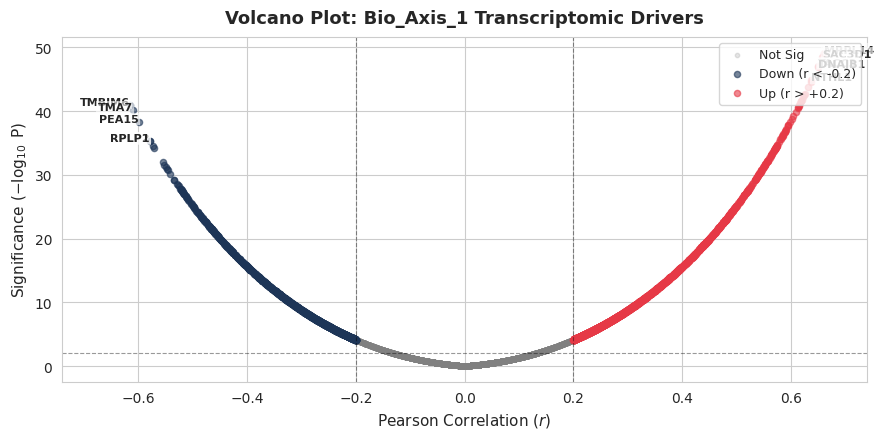


🎯 Bio_Axis_2 | Canonical Correlation ($r$): 0.9528
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ATP6V0B (+0.55), UPP1 (+0.51), CEBPB (+0.50), ATG101 (+0.49), DDIT3 (+0.48)
  ↳ Key Downregulated : TUBA1B (-0.56), LOXL1 (-0.53), TYMS (-0.52), PCLAF (-0.51), SCARA3 (-0.50)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • autophagosome assembly (GO:0000045)                  | NES: +2.29 | FDR: 0.00e+00
     • autophagosome organization (GO:1905037)              | NES: +2.27 | FDR: 0.00e+00
     • phagosome acidification (GO:0090383)                 | NES: +2.25 | FDR: 0.00e+00
     • response to endoplasmic reticulum stress (GO:0034976 | NES: +2.24 | FDR: 0.00e+00
     • intrinsic apoptotic signaling pathway in response to | NES: +2.21 | FDR: 1.02e-03

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • cytoplasmic translation (GO:0002181)                 | NES: -2.72 | FDR: 0.00e+00
     • SRP-dependent cotranslational protein targeting to m | NES: -2.71 | FD

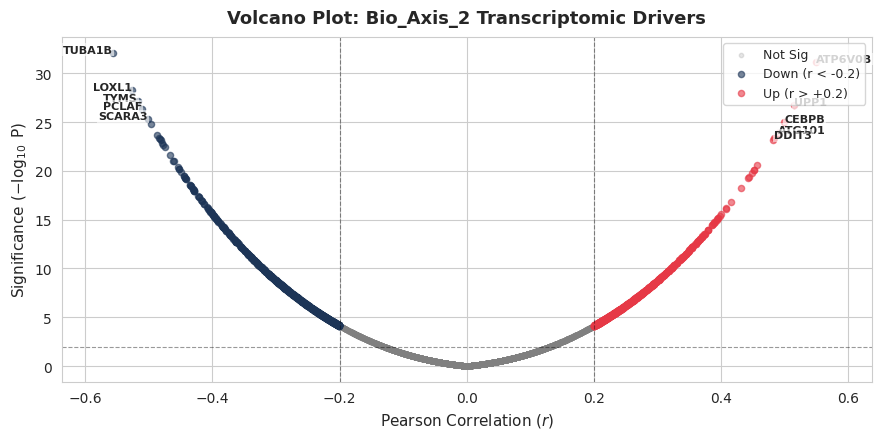


🎯 Bio_Axis_3 | Canonical Correlation ($r$): 0.9496
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : GAST (+0.60), CYP4F2 (+0.60), IRGM (+0.58), MIR7-3HG (+0.56), VN2R19P (+0.56)
  ↳ Key Downregulated : TRIP6 (-0.60), SHISA5 (-0.58), NEK6 (-0.54), SCRN1 (-0.53), RAB34 (-0.52)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • cytoplasmic translation (GO:0002181)                 | NES: +2.35 | FDR: 3.72e-03
     • cotranslational protein targeting to membrane (GO:00 | NES: +2.34 | FDR: 1.86e-03
     • SRP-dependent cotranslational protein targeting to m | NES: +2.34 | FDR: 1.24e-03
     • response to zinc ion (GO:0010043)                    | NES: +2.29 | FDR: 9.29e-04
     • protein targeting to ER (GO:0045047)                 | NES: +2.24 | FDR: 7.43e-04

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • negative regulation of mitotic cell cycle phase tran | NES: -2.39 | FDR: 0.00e+00
     • negative regulation of G2/M transition of mitotic ce | NES: -2.34 | F

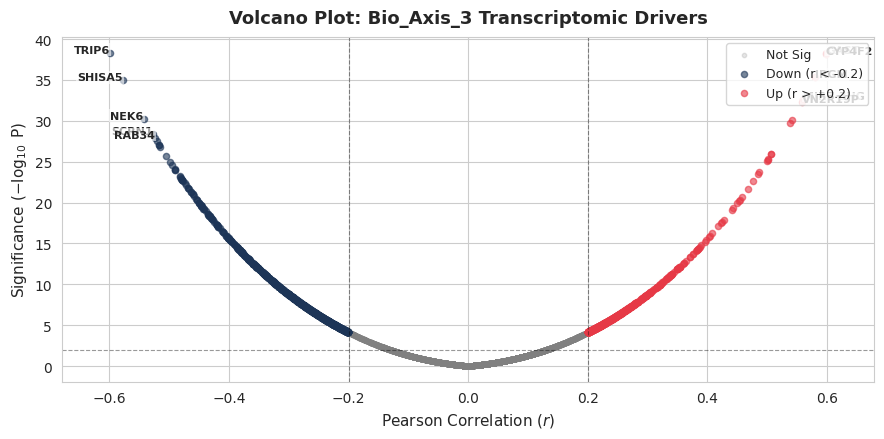


🎯 Bio_Axis_4 | Canonical Correlation ($r$): 0.9336
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ATP6V0D2 (+0.49), IL1A (+0.35), MMP1 (+0.34), SPINK1 (+0.33), NOP53 (+0.31)
  ↳ Key Downregulated : ID1 (-0.45), CCN2 (-0.39), SPTAN1 (-0.38), FSTL3 (-0.35), CKB (-0.35)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • cotranslational protein targeting to membrane (GO:00 | NES: +2.63 | FDR: 0.00e+00
     • SRP-dependent cotranslational protein targeting to m | NES: +2.60 | FDR: 0.00e+00
     • protein targeting to ER (GO:0045047)                 | NES: +2.54 | FDR: 0.00e+00
     • nuclear-transcribed mRNA catabolic process, nonsense | NES: +2.29 | FDR: 0.00e+00
     • cytoplasmic translation (GO:0002181)                 | NES: +2.21 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • retina homeostasis (GO:0001895)                      | NES: -2.14 | FDR: 1.87e-01
     • regulation of microtubule polymerization or depolyme | NES: -2.10 | FDR: 1.

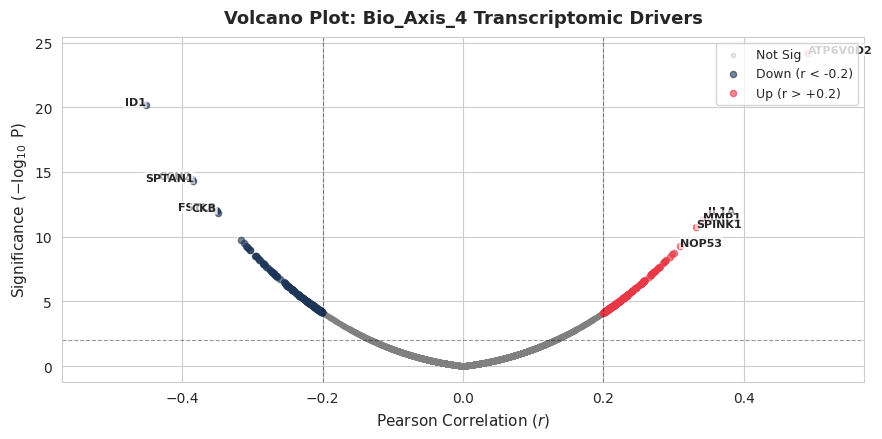


🎯 Bio_Axis_5 | Canonical Correlation ($r$): 0.9096
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : HNRNPD (+0.39), SMG9 (+0.38), MCM3 (+0.38), NDUFS2 (+0.38), CNOT1 (+0.38)
  ↳ Key Downregulated : SNORD3B-2 (-0.43), IER3 (-0.41), CCL2 (-0.38), SNORD3A (-0.38), PHLDA2 (-0.37)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • DNA replication (GO:0006260)                         | NES: +2.67 | FDR: 0.00e+00
     • microtubule cytoskeleton organization involved in mi | NES: +2.59 | FDR: 0.00e+00
     • DNA metabolic process (GO:0006259)                   | NES: +2.53 | FDR: 0.00e+00
     • mitotic spindle organization (GO:0007052)            | NES: +2.50 | FDR: 0.00e+00
     • negative regulation of cell cycle process (GO:001094 | NES: +2.49 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • SRP-dependent cotranslational protein targeting to m | NES: -3.21 | FDR: 0.00e+00
     • cotranslational protein targeting to membrane (GO:00 | NES: -3.16 | 

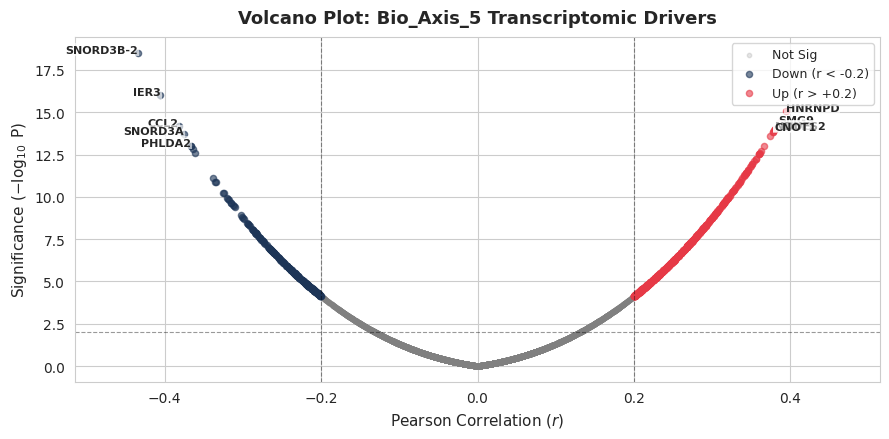


🎯 Bio_Axis_6 | Canonical Correlation ($r$): 0.8971
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : CRCT1 (+0.63), SPRR2B (+0.60), SPRR2E (+0.59), LOC101928994 (+0.55), RCSD1 (+0.51)
  ↳ Key Downregulated : TRPV2 (-0.45), SCG2 (-0.41), CXCL2 (-0.37), GOLPH3-DT (-0.35), DHRS9 (-0.34)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • cotranslational protein targeting to membrane (GO:00 | NES: +3.50 | FDR: 0.00e+00
     • SRP-dependent cotranslational protein targeting to m | NES: +3.40 | FDR: 0.00e+00
     • protein targeting to ER (GO:0045047)                 | NES: +3.40 | FDR: 0.00e+00
     • cytoplasmic translation (GO:0002181)                 | NES: +3.36 | FDR: 0.00e+00
     • nuclear-transcribed mRNA catabolic process, nonsense | NES: +3.25 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • negative regulation of transcription by RNA polymera | NES: -1.96 | FDR: 3.35e-01
     • in utero embryonic development (GO:0001701)          | NES: -

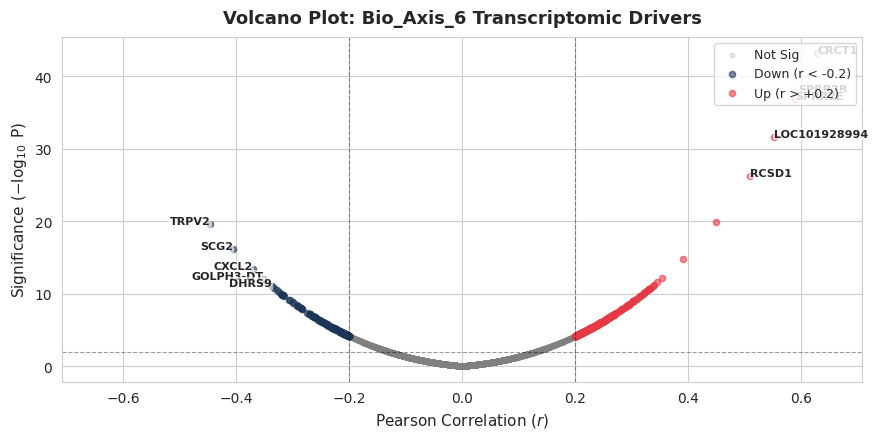


🎯 Bio_Axis_7 | Canonical Correlation ($r$): 0.8787
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : CSF3 (+0.52), SGPP2 (+0.48), TRA2B (+0.39), MLC1 (+0.37), VCF1 (+0.36)
  ↳ Key Downregulated : H2BK1 (-0.30), LINC00520 (-0.28), TNFRSF10B-AS1 (-0.27), NPC2 (-0.27), ZNF571 (-0.27)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • RNA splicing, via transesterification reactions with | NES: +2.94 | FDR: 0.00e+00
     • mRNA processing (GO:0006397)                         | NES: +2.94 | FDR: 0.00e+00
     • mRNA splicing, via spliceosome (GO:0000398)          | NES: +2.79 | FDR: 0.00e+00
     • regulation of mRNA splicing, via spliceosome (GO:004 | NES: +2.70 | FDR: 0.00e+00
     • DNA-dependent DNA replication (GO:0006261)           | NES: +2.63 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • glycosphingolipid metabolic process (GO:0006687)     | NES: -2.36 | FDR: 4.05e-03
     • secondary alcohol biosynthetic process (GO:1902653)  | NES: -2.3

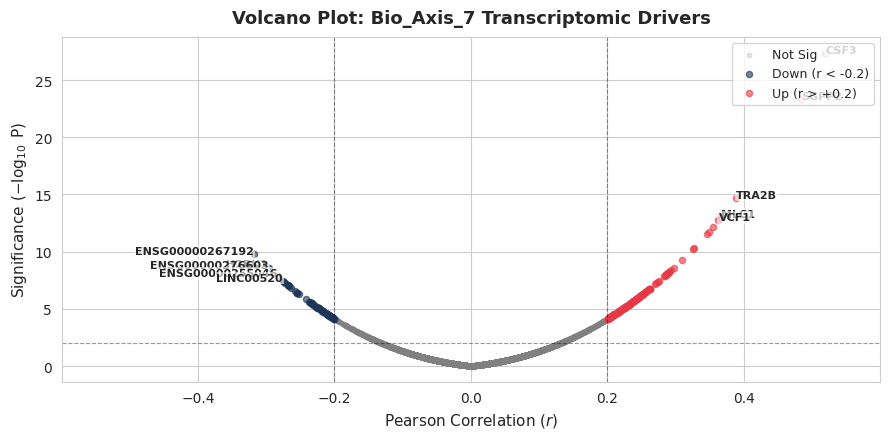


🎯 Bio_Axis_8 | Canonical Correlation ($r$): 0.8657
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : TFDP1 (+0.51), THY1 (+0.48), CRABP2 (+0.45), HNRNPA2B1 (+0.45), GLS (+0.44)
  ↳ Key Downregulated : BRI3 (-0.57), SMIM29 (-0.53), EPB41L4A-AS1 (-0.51), SQSTM1 (-0.50), GLRX (-0.47)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • CENP-A containing nucleosome assembly (GO:0034080)   | NES: +2.54 | FDR: 0.00e+00
     • CENP-A containing chromatin organization (GO:0061641 | NES: +2.54 | FDR: 0.00e+00
     • microtubule cytoskeleton organization involved in mi | NES: +2.53 | FDR: 0.00e+00
     • chromatin remodeling at centromere (GO:0031055)      | NES: +2.51 | FDR: 0.00e+00
     • histone exchange (GO:0043486)                        | NES: +2.46 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • protein targeting to ER (GO:0045047)                 | NES: -2.92 | FDR: 0.00e+00
     • cytoplasmic translation (GO:0002181)                 | NES: -2.9

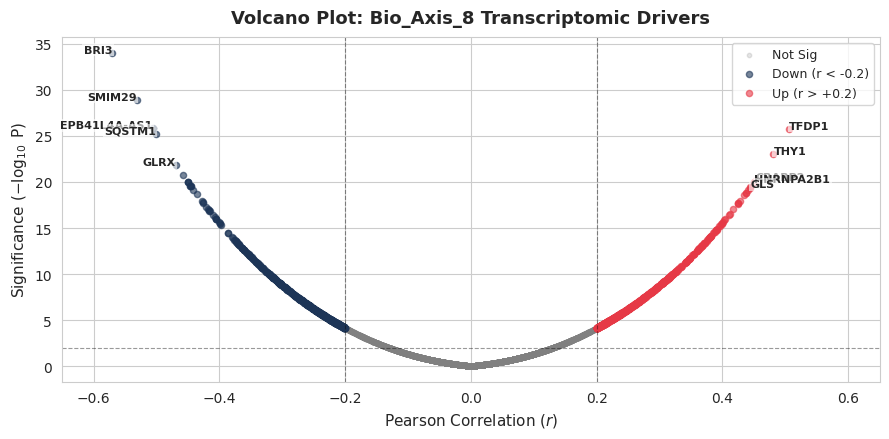


🎯 Bio_Axis_9 | Canonical Correlation ($r$): 0.8456
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : CXCL2 (+0.30), CRCT1 (+0.30), HSPB8 (+0.28), SNX25 (+0.28), CPEB2 (+0.27)
  ↳ Key Downregulated : FLOT1 (-0.35), GPAA1 (-0.34), NDUFV1 (-0.32), SNF8 (-0.32), DCTN3 (-0.31)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • mRNA modification (GO:0016556)                       | NES: +2.09 | FDR: 3.97e-02
     • cellular response to chemokine (GO:1990869)          | NES: +2.04 | FDR: 6.94e-02
     • phosphatidylinositol biosynthetic process (GO:000666 | NES: +1.97 | FDR: 1.29e-01
     • cellular response to vascular endothelial growth fac | NES: +1.96 | FDR: 1.07e-01
     • chemokine-mediated signaling pathway (GO:0070098)    | NES: +1.94 | FDR: 1.26e-01

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • cotranslational protein targeting to membrane (GO:00 | NES: -3.79 | FDR: 0.00e+00
     • protein targeting to ER (GO:0045047)                 | NES: -3.67 | FDR: 

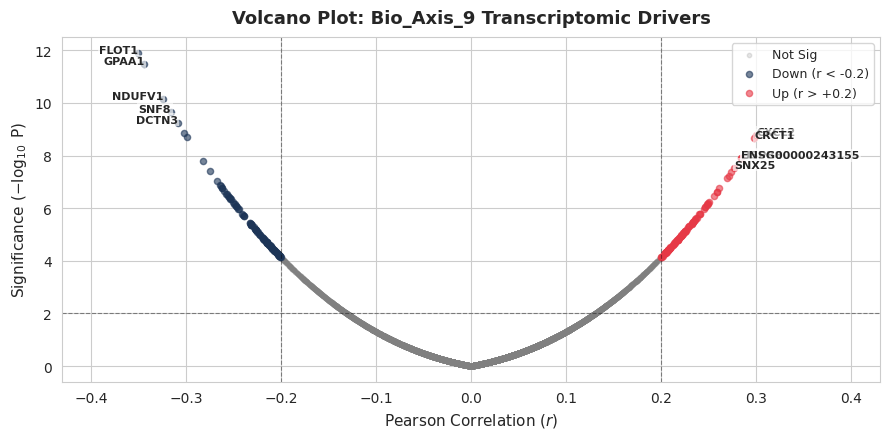


🎯 Bio_Axis_10 | Canonical Correlation ($r$): 0.8204
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : HK2 (+0.34), CCT5 (+0.33), CCT4 (+0.32), ZNF207 (+0.31), HSPD1 (+0.29)
  ↳ Key Downregulated : TSTD1 (-0.30), FGFBP3 (-0.29), OXLD1 (-0.29), P4HTM (-0.27), LOC730098 (-0.27)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • ribosome biogenesis (GO:0042254)                     | NES: +3.08 | FDR: 0.00e+00
     • rRNA processing (GO:0006364)                         | NES: +3.08 | FDR: 0.00e+00
     • anaphase-promoting complex-dependent catabolic proce | NES: +2.96 | FDR: 0.00e+00
     • cytoplasmic translation (GO:0002181)                 | NES: +2.96 | FDR: 0.00e+00
     • rRNA metabolic process (GO:0016072)                  | NES: +2.95 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • negative regulation of axon extension involved in ax | NES: -1.97 | FDR: 4.12e-01
     • kidney development (GO:0001822)                      | NES: -1.95 | FD

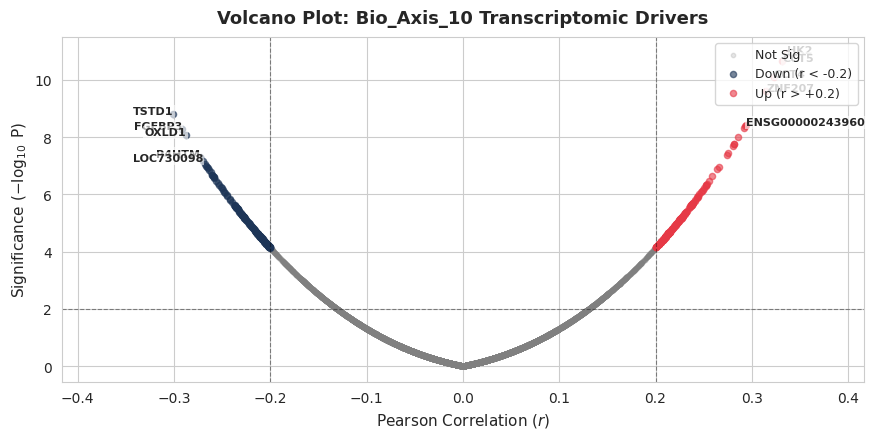


🏁 MINIMOL MULTIMODAL DECODING COMPLETE ACROSS ALL 10 AXES


In [ ]:
import os
import gc
import re
import warnings
import requests
from collections import Counter
import numpy as np
import pandas as pd
import duckdb
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import mannwhitneyu, t as t_dist

# Auto-install bioinformatics packages if missing
for pkg in ['mygene', 'gseapy']:
    try:
        __import__(pkg)
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import mygene
import gseapy as gp

warnings.filterwarnings('ignore')

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & SELF-HEALING HARDWARE SETUP
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cpu')
if torch.cuda.is_available():
    try:
        _test = torch.zeros(1, device='cuda') + 1
        device = torch.device('cuda')
        print(f"⚡ Acceleration Engine: GPU Verified ({torch.cuda.get_device_name(0)})")
    except Exception:
        print(f"⚠️ GPU detected ({torch.cuda.get_device_name(0)}), but PyTorch lacks matching kernel images.")
        print("⚡ Automatically falling back to high-throughput CPU (PyTorch MKL). Executing safely!")
        device = torch.device('cpu')
else:
    print("⚡ Running on CPU.")

# ==============================================================================
# 🌐 1. UPGRADED 3-TIER ANNOTATION ENGINE (PubChem + ChEMBL Block-1 Rescue)
# ==============================================================================
ANNOTATION_CACHE = {}

def get_rich_compound_annotation(inchikey):
    """
    3-Tier Annotation Engine:
    1. PubChem Synonyms (captures research codes & generic names)
    2. ChEMBL with Part II Block-1 Rescue (startswith[:14])
    3. ChEMBL IC50 Potency Targets (< 500nM) for non-clinical tool compounds
    """
    if inchikey in ANNOTATION_CACHE:
        return ANNOTATION_CACHE[inchikey]

    name = "Unknown"
    moa = "Unannotated"
    cid = None

    # --- TIER 1: PubChem Synonyms (Best for developmental codes & drug names) ---
    try:
        url_syn = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{inchikey}/synonyms/JSON"
        r = requests.get(url_syn, timeout=4)
        if r.status_code == 200:
            info = r.json().get('InformationList', {}).get('Information', [{}])[0]
            cid = info.get('CID')
            synonyms = info.get('Synonym', [])

            for s in synonyms[:15]:
                if not re.match(r'^\d+-\d+-\d+$', s) and len(s) > 2:
                    if not any(s.startswith(prefix) for prefix in ['SCHEMBL', 'CHEMBL', 'AKOS', 'CS-', 'EN300']):
                        name = s
                        break
    except Exception:
        pass

    # --- TIER 2: ChEMBL with Part II Block 1 Rescue ---
    chembl_id = None
    try:
        url_chembl = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key={inchikey}"
        r = requests.get(url_chembl, timeout=4)
        mols = r.json().get('molecules', []) if r.status_code == 200 else []

        # Block 1 Rescue (First 14 chars) if exact match fails
        if not mols and len(inchikey) >= 14:
            b1 = inchikey[:14]
            url_b1 = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key__startswith={b1}"
            r = requests.get(url_b1, timeout=4)
            mols = r.json().get('molecules', []) if r.status_code == 200 else []

        if mols:
            mol = mols[0]
            chembl_id = mol.get('molecule_chembl_id')
            if name == "Unknown" and mol.get('pref_name'):
                name = mol.get('pref_name')

            # Check curated clinical mechanism
            url_mech = f"https://www.ebi.ac.uk/chembl/api/data/mechanism.json?molecule_chembl_id={chembl_id}"
            r_m = requests.get(url_mech, timeout=4)
            if r_m.status_code == 200:
                mechs = r_m.json().get('mechanisms', [])
                if mechs:
                    moa = mechs[0].get('mechanism_of_action')

            # --- TIER 3: ChEMBL Bioactivity Target Fallback (< 500nM) ---
            if moa == "Unannotated" and chembl_id:
                url_act = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?molecule_chembl_id={chembl_id}&standard_type=IC50&standard_value__lte=500&limit=1"
                r_a = requests.get(url_act, timeout=4)
                if r_a.status_code == 200:
                    acts = r_a.json().get('activities', [])
                    if acts and acts[0].get('target_pref_name'):
                        target = acts[0].get('target_pref_name')
                        moa = f"{target} inhibitor (IC50 < 500nM)"
    except Exception:
        pass

    ANNOTATION_CACHE[inchikey] = (name, moa)
    return name, moa

# ==============================================================================
# ⚙️ 2. CONFIGURATION & RESTORATION OF LEADERBOARD WINNER
# ==============================================================================
MERGE_KEY = "InChIKey"
NUM_AXES_TO_ANALYZE = 10
MINIMOL_URI = "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__full_final.parquet"
LOCAL_MINIMOL_CACHE = "cached_minimol_embeddings_full_final.parquet"
RNA_CACHE = "cached_drugseq_24_48h.parquet"

top_model_name = leaderboard_df.iloc[0]["Model / Processing"]
top_score = leaderboard_df.iloc[0]["SVCCA Mean (AUC)"]

print("="*95)
print(f"🏆 DECODING WINNING MODEL: [{top_model_name}] (SVCCA Mean AUC: {top_score:.4f})")
print(f"🔬 Structural Target Space: Minimol 512D Pre-Computed Parquet")
print(f"🎯 Decoding Horizon: Top {NUM_AXES_TO_ANALYZE} Biological Axes")
print("="*95)

conn = duckdb.connect()

# 2A. Load Winner Morphology & Apply Median Replicate Aggregation
winner_cache = f"cached_{top_model_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')}.parquet"
print(f"📂 Loading winner morphology from: {winner_cache}...")
morph_df = conn.execute(f"SELECT * FROM read_parquet('{winner_cache}')").df()

for col in morph_df.columns:
    if 'inchikey' in col.lower():
        morph_df = morph_df.rename(columns={col: MERGE_KEY})
        break

group_cols = [MERGE_KEY]
for candidates in [
    ['concentration', 'Metadata_Concentration', 'pert_dose', 'pert_dose_uM', 'dose'],
    ['Metadata_Time', 'pert_time', 'pert_time_h', 'time', 'timepoint'],
    ['Metadata_cell_line', 'Metadata_CellLine', 'Metadata_cell_type', 'cell_line', 'cell_type']
]:
    for c in candidates:
        if c in morph_df.columns and c not in group_cols:
            group_cols.append(c)
            break

morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns
                  if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid'] + group_cols]

raw_wells = len(morph_df)
morph_df = morph_df.groupby(group_cols, as_index=False, dropna=False)[morph_features].median()
morph_df = morph_df.sort_values(by=group_cols, kind='stable').reset_index(drop=True)
print(f"  ↳ Consolidated {raw_wells} morphology wells into {len(morph_df)} median treatment profiles.")

# 2B. Ensure drugseq_pooled is in memory
if 'drugseq_pooled' not in globals():
    print(f"📂 Reloading DRUG-seq pooled from cache: {RNA_CACHE}...")
    drugseq_raw = conn.execute(f"SELECT * FROM read_parquet('{RNA_CACHE}')").df()
    for col in drugseq_raw.columns:
        if 'inchikey' in col.lower():
            drugseq_raw = drugseq_raw.rename(columns={col: MERGE_KEY})
            break
    d_features = [c for c in drugseq_raw.select_dtypes(include=[np.number]).columns
                  if c not in [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']]
    grouped = drugseq_raw.groupby(MERGE_KEY)[d_features]
    def pool_func(x):
        idx = np.argmax(np.abs(x.values), axis=0)
        return x.values[idx, np.arange(x.shape[1])]
    drugseq_pooled = pd.DataFrame(grouped.apply(pool_func).tolist(),
                                  index=grouped.apply(pool_func).index,
                                  columns=d_features).reset_index()
    drugseq_features = d_features

# 2C. Load Minimol Parquet Directly
if not os.path.exists(LOCAL_MINIMOL_CACHE):
    print("📥 Streaming Minimol Parquet from GCS to local cache...")
    gcs = GcsFileSystem()
    minimol_path = MINIMOL_URI.replace("gs://", "")
    minimol_ds = ds.dataset(minimol_path, filesystem=gcs, format="parquet")
    conn.execute(f"COPY (SELECT * FROM minimol_ds) TO '{LOCAL_MINIMOL_CACHE}' (FORMAT PARQUET)")

minimol_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_MINIMOL_CACHE}')").df()
conn.close()

if 'Metadata_InChIKey_x' in minimol_df.columns:
    minimol_df = minimol_df.rename(columns={'Metadata_InChIKey_x': MERGE_KEY})
elif 'Metadata_InChIKey_y' in minimol_df.columns:
    minimol_df = minimol_df.rename(columns={'Metadata_InChIKey_y': MERGE_KEY})
else:
    for col in minimol_df.columns:
        if 'inchikey' in col.lower():
            minimol_df = minimol_df.rename(columns={col: MERGE_KEY})
            break

minimol_features = [c for c in minimol_df.columns if c.startswith('Mini_Dim_')]
if len(minimol_features) == 0:
    minimol_features = [c for c in minimol_df.select_dtypes(include=[np.number]).columns
                        if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid']]

minimol_matrix = np.nan_to_num(minimol_df[minimol_features].values.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
minimol_df[minimol_features] = minimol_matrix

valid_mask = np.linalg.norm(minimol_matrix, axis=1) > 1e-6
minimol_df = minimol_df[valid_mask].copy()
minimol_df = minimol_df.sort_values(by=MERGE_KEY, kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)
print(f"✅ Minimol ready: {len(minimol_df)} unique molecules with {len(minimol_features)} dimensions.")

# ==============================================================================
# ⚡ 3. EXACT CLOSED-FORM SVCCA PROJECTION
# ==============================================================================
aligned_df = pd.merge(morph_df, drugseq_pooled, on=MERGE_KEY, how="inner")
aligned_df = aligned_df.sort_values(by=group_cols, kind='stable').reset_index(drop=True)

X_m = torch.tensor(np.nan_to_num(aligned_df[morph_features].values.astype(np.float64)), device=device)
Y_r = torch.tensor(np.nan_to_num(aligned_df[drugseq_features].values.astype(np.float64)), device=device)
active_inchikeys = aligned_df[MERGE_KEY].values

k_decomp = min(50, int(len(aligned_df) * 0.8))

X_m = X_m - X_m.mean(dim=0)
Y_r = Y_r - Y_r.mean(dim=0)

def get_exact_basis_deterministic(M, k):
    G = torch.matmul(M, M.T)
    eigvals, eigvecs = torch.linalg.eigh(G)
    idx = torch.argsort(eigvals, descending=True)[:k]
    U_k = eigvecs[:, idx]
    max_idx = torch.argmax(torch.abs(U_k), dim=0)
    col_signs = torch.sign(U_k[max_idx, range(k)])
    col_signs[col_signs == 0] = 1.0
    return U_k * col_signs

Qa = get_exact_basis_deterministic(X_m, k_decomp)
Qb = get_exact_basis_deterministic(Y_r, k_decomp)

U, S, Vt = torch.linalg.svd(torch.matmul(Qa.T, Qb))

max_abs_cols = torch.argmax(torch.abs(U), dim=0)
signs = torch.sign(U[max_abs_cols, range(U.shape[1])])
signs[signs == 0] = 1.0
U = U * signs

bio_canonical_scores = torch.matmul(Qa, U[:, :NUM_AXES_TO_ANALYZE]).cpu().numpy()
axis_cols = [f'Bio_Axis_{i+1}' for i in range(NUM_AXES_TO_ANALYZE)]
bio_scores_df = pd.DataFrame(bio_canonical_scores, columns=axis_cols)
bio_scores_df[MERGE_KEY] = active_inchikeys

print(f"✅ Projection Complete: {len(aligned_df)} consensus treatments projected onto {NUM_AXES_TO_ANALYZE} axes.")

# ==============================================================================
# 🧬 4. MAP GENE SYMBOLS (MYGENE)
# ==============================================================================
print("Querying MyGene for official HGNC symbols...")
mg = mygene.MyGeneInfo()
clean_ensembl_ids = [g.split('.')[0] for g in drugseq_features]
gene_info = mg.querymany(clean_ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=False)
ensembl_to_symbol = {h['query']: h['symbol'] for h in gene_info if 'query' in h and 'symbol' in h}
print(f"✅ Mapped {len(ensembl_to_symbol)} of {len(drugseq_features)} genes.")

# ==============================================================================
# 🔍 5. UNIFIED MULTIMODAL AXIS DECODER (MINIMOL + RNA + 3-TIER ANNOTATION)
# ==============================================================================
merged_all = pd.merge(bio_scores_df, drugseq_pooled, on=MERGE_KEY, how='inner')
merged_all = merged_all.sort_values(by=MERGE_KEY, kind='stable').reset_index(drop=True)

# 💡 FIX 1: Sanitize RNA matrix upfront so NaNs never infect the covariance math
clean_rna_matrix = np.nan_to_num(merged_all[drugseq_features].values.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
all_genes_tensor = torch.tensor(clean_rna_matrix, device=device)
Y_c_genes = all_genes_tensor - all_genes_tensor.mean(dim=0)
var_Y_genes = torch.sum(Y_c_genes ** 2, dim=0)

for axis_idx in range(NUM_AXES_TO_ANALYZE):
    axis_name = f'Bio_Axis_{axis_idx+1}'
    canonical_corr = S[axis_idx].item()

    print("\n" + "="*95)
    print(f"🎯 {axis_name} | Canonical Correlation ($r$): {canonical_corr:.4f}")
    print("="*95)

    # -------------------------------------------------------------------------
    # PART A: TRANSCRIPTIONAL DECODING (Pearson r + GSEA)
    # -------------------------------------------------------------------------
    axis_tensor = torch.tensor(merged_all[axis_name].values.astype(np.float64), device=device)
    X_c_axis = axis_tensor - axis_tensor.mean()
    var_X_axis = torch.sum(X_c_axis ** 2)

    cov = torch.matmul(X_c_axis, Y_c_genes)
    r_tensor = cov / torch.sqrt(var_X_axis * var_Y_genes + 1e-12)

    n_samples = len(merged_all)
    r_clipped = torch.clamp(r_tensor, -0.9999, 0.9999)
    t_stat = r_clipped * torch.sqrt((n_samples - 2) / (1.0 - r_clipped**2))

    r_vals = r_tensor.cpu().numpy()
    t_vals = t_stat.cpu().numpy()
    p_vals = 2 * t_dist.sf(np.abs(t_vals), df=n_samples - 2)
    neg_log10_p = -np.log10(p_vals + 1e-300)

    symbols = [ensembl_to_symbol.get(g.split('.')[0], g) for g in drugseq_features]
    gene_df = pd.DataFrame({
        'Ensembl_ID': drugseq_features,
        'Gene_Symbol': symbols,
        'Correlation': r_vals,
        'P_Value': p_vals,
        'Neg_Log10_P': neg_log10_p
    })

    # 💡 FIX 2: Explicitly drop any remaining NaNs so they never pollute the head or tail!
    valid_genes = gene_df.dropna(subset=['Correlation']).copy()
    valid_genes = valid_genes[~valid_genes['Gene_Symbol'].str.startswith('ENSG')].copy()
    valid_genes['abs_corr'] = valid_genes['Correlation'].abs()

    dedup_ranks = valid_genes.sort_values(by=['abs_corr', 'Gene_Symbol'], ascending=[False, True], kind='stable').drop_duplicates('Gene_Symbol')
    rnk_input = dedup_ranks[['Gene_Symbol', 'Correlation']].sort_values(by=['Correlation', 'Gene_Symbol'], ascending=[False, True], kind='stable')

    top_pos_genes = rnk_input.head(5)
    top_neg_genes = rnk_input.tail(5).iloc[::-1]

    print("🧬 TRANSCRIPTIONAL SIGNATURE:")
    print(f"  ↳ Key Upregulated   : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_pos_genes.iterrows()]))
    print(f"  ↳ Key Downregulated : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_neg_genes.iterrows()]))

    # GSEA Prerank
    try:
        pre_res = gp.prerank(
            rnk=rnk_input,
            gene_sets='GO_Biological_Process_2021',
            threads=1,
            min_size=10,
            max_size=500,
            permutation_num=200,
            outdir=None,
            seed=42
        )
        res_df = pre_res.res2d
        top_pos_pw = res_df[res_df['NES'] > 0].sort_values(by='NES', ascending=False, kind='stable').head(5)
        top_neg_pw = res_df[res_df['NES'] < 0].sort_values(by='NES', ascending=True, kind='stable').head(5)

        print("\n  🟢 Top 5 Positively Enriched Pathways (Upregulated):")
        if len(top_pos_pw) > 0:
            for _, r_pw in top_pos_pw.iterrows():
                print(f"     • {r_pw['Term'][:52]:<52} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")

        print("\n  🔴 Top 5 Negatively Enriched Pathways (Suppressed):")
        if len(top_neg_pw) > 0:
            for _, r_pw in top_neg_pw.iterrows():
                print(f"     • {r_pw['Term'][:52]:<52} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")
    except Exception as e:
        print(f"  ↳ GSEA note: {e}")

    # -------------------------------------------------------------------------
    # PART B: MINIMOL STRUCTURAL CLUSTERING & 3-TIER COMPOUND ANNOTATION
    # -------------------------------------------------------------------------
    merged_struct = pd.merge(bio_scores_df[[MERGE_KEY, axis_name]], minimol_df, on=MERGE_KEY, how='inner')
    merged_struct = merged_struct.sort_values(by=[axis_name, MERGE_KEY], ascending=[False, True], kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first')

    scores = merged_struct[axis_name].values
    cutoff = np.mean(scores) + (2.0 * np.std(scores))
    top_drivers = merged_struct[merged_struct[axis_name] > cutoff].copy()
    if len(top_drivers) < 5:
        top_drivers = merged_struct.head(15).copy()

    k_drivers = len(top_drivers)

    drivers_tensor = torch.tensor(top_drivers[minimol_features].values.astype(np.float32), device=device)
    random_group = merged_struct.sample(n=k_drivers, random_state=42)
    random_tensor = torch.tensor(random_group[minimol_features].values.astype(np.float32), device=device)

    def get_pairwise_sims(tensor):
        normed = torch.nn.functional.normalize(tensor, p=2, dim=1)
        sim_mat = torch.matmul(normed, normed.T)
        k = tensor.shape[0]
        triu_indices = torch.triu_indices(k, k, offset=1, device=device)
        return sim_mat[triu_indices[0], triu_indices[1]].cpu().numpy()

    driver_sims = get_pairwise_sims(drivers_tensor)
    random_sims = get_pairwise_sims(random_tensor)

    mean_driver_sim = np.mean(driver_sims)
    mean_random_sim = np.mean(random_sims)

    _, p_val = mannwhitneyu(driver_sims, random_sims, alternative='greater')
    fold_change = mean_driver_sim / (mean_random_sim + 1e-8)

    print("\n🧪 MINIMOL 2D STRUCTURAL SIGNATURE:")
    print(f"  ↳ Driver Compounds Evaluated : {k_drivers} unique molecules")
    print(f"  ↳ Mean Minimol Cosine Sim    : Drivers = {mean_driver_sim:.4f} | Background = {mean_random_sim:.4f}")
    print(f"  ↳ Enrichment Fold Change     : {fold_change:.2f}x (Mann-Whitney p = {p_val:.2e})")

    if p_val < 0.01 and fold_change > 1.02:
        verdict = "✅ DISTINCT 2D PHARMACOPHORE CLUSTER (Rigid Chemical Scaffold)"
    elif p_val < 0.05:
        verdict = "⚠️ WEAK STRUCTURAL CLUSTERING (Shared Sub-structure / Heterogeneous Series)"
    else:
        verdict = "💡 DIVERSE 2D CHEMISTRY (Scaffold Hopping / Phenotypic Convergence)"
    print(f"  ↳ Structural Verdict         : {verdict}")

    # 3-TIER AUTO-ANNOTATION READOUT
    top_keys = top_drivers.head(5)[MERGE_KEY].tolist()
    top_scores = top_drivers.head(5)[axis_name].tolist()

    print("\n  ↳ Top 5 Driving Compounds (Auto-Annotated via PubChem / ChEMBL):")
    moa_list = []

    for rank, (ikey, sc) in enumerate(zip(top_keys, top_scores), 1):
        name, moa = get_rich_compound_annotation(ikey)
        if moa != "Unannotated":
            moa_list.append(moa)
        print(f"     {rank}. {name:<22} | {moa:<38} | Score: {sc:+.3f} | {ikey}")

    # Detect Consensus Mechanism
    if moa_list:
        most_common_moa, count = Counter(moa_list).most_common(1)[0]
        if count >= 2:
            print(f"  🎯 CONSENSUS MECHANISM FOUND: '{most_common_moa}' ({count}/{len(top_keys)} compounds share this)")
        else:
            print(f"  💡 TARGET DIVERSITY: Multiple distinct targets annotated ({', '.join(set(moa_list))})")
    else:
        print("  ⚠️ NO CURATED TARGETS: Compounds may be novel unannotated screening hits.")

    # -------------------------------------------------------------------------
    # PART C: COMPACT VOLCANO PLOT
    # -------------------------------------------------------------------------
    plt.figure(figsize=(9, 4.5), dpi=100)
    sns.set_style("whitegrid")
    r_thresh, p_thresh = 0.20, 0.01
    p_log_thresh = -np.log10(p_thresh)

    up_sig = gene_df[(gene_df['Correlation'] > r_thresh) & (gene_df['P_Value'] < p_thresh)]
    down_sig = gene_df[(gene_df['Correlation'] < -r_thresh) & (gene_df['P_Value'] < p_thresh)]
    not_sig = gene_df[(np.abs(gene_df['Correlation']) <= r_thresh) | (gene_df['P_Value'] >= p_thresh)]

    plt.scatter(not_sig['Correlation'], not_sig['Neg_Log10_P'], color='gray', alpha=0.2, s=10, label='Not Sig')
    plt.scatter(down_sig['Correlation'], down_sig['Neg_Log10_P'], color='#1D3557', alpha=0.6, s=20, label=f'Down (r < -{r_thresh})')
    plt.scatter(up_sig['Correlation'], up_sig['Neg_Log10_P'], color='#E63946', alpha=0.6, s=20, label=f'Up (r > +{r_thresh})')

    top_label = pd.concat([
        up_sig.sort_values(by='Correlation', ascending=False, kind='stable').head(5),
        down_sig.sort_values(by='Correlation', ascending=True, kind='stable').head(5)
    ])

    for _, r_lbl in top_label.iterrows():
        plt.text(r_lbl['Correlation'], r_lbl['Neg_Log10_P'], r_lbl['Gene_Symbol'],
                 fontsize=8, fontweight='bold', ha='left' if r_lbl['Correlation'] > 0 else 'right',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    plt.axvline(x=r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.axvline(x=-r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.axhline(y=p_log_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)

    max_c = max(np.abs(gene_df['Correlation'].min()), np.abs(gene_df['Correlation'].max()))
    plt.xlim(-max_c - 0.08, max_c + 0.08)
    plt.title(f'Volcano Plot: {axis_name} Transcriptomic Drivers', fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Pearson Correlation ($r$)', fontsize=11)
    plt.ylabel('Significance ($-\\log_{10}$ P)', fontsize=11)
    plt.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

print("\n" + "="*95)
print("🏁 MINIMOL MULTIMODAL DECODING COMPLETE ACROSS ALL 10 AXES")
print("="*95)

# How do aligned axis compare to individual axis?

In [ ]:
import os
import gc
import warnings
import numpy as np
import pandas as pd
import duckdb
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem
import torch
from scipy.stats import hypergeom

warnings.filterwarnings('ignore')

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & HARDWARE SETUP
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Acceleration Engine: {device}")

# ==============================================================================
# ⚙️ 1. PARQUET SOURCES & DYNAMIC WINNER RESTORATION
# ==============================================================================
MERGE_KEY = "InChIKey"
K_NEIGHBORS = 10        # Top k nearest neighbors to evaluate per space
NUM_AXES_TO_EVAL = 3    # Evaluate drivers for Top 3 SVCCA axes

# Source URIs & Caches
top_model_name = leaderboard_df.iloc[0]["Model / Processing"] if 'leaderboard_df' in globals() else "DINO (Normed + Actives)"
MORPH_CACHE = f"cached_{top_model_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')}.parquet"
RNA_CACHE = "cached_drugseq_24_48h.parquet"

MINIMOL_URI = "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__full_final.parquet"
LOCAL_MINIMOL_CACHE = "cached_minimol_embeddings_full_final.parquet"

CC_URI = "gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/JUMP_CP_Global_Signatures_full.parquet"
LOCAL_CC_CACHE = "cached_chemchecker_embeddings.parquet"

print("="*95)
print(f"🚀 INGESTING PARQUET SOURCES FOR MULTIMODAL LOCAL TOPOLOGY SWEEP")
print(f"  ↳ Morphology Winner : {MORPH_CACHE}")
print(f"  ↳ Transcriptomics   : {RNA_CACHE}")
print(f"  ↳ Chemistry (2D)    : {LOCAL_MINIMOL_CACHE}")
print(f"  ↳ Chemistry (Target): {LOCAL_CC_CACHE}")
print("="*95)

conn = duckdb.connect()
gcs = GcsFileSystem()

# ------------------------------------------------------------------------------
# 2. INGEST & HARMONIZE ALL 4 MODALITIES
# ------------------------------------------------------------------------------
# A. Morphology (with Median Replicate Aggregation)
morph_df = conn.execute(f"SELECT * FROM read_parquet('{MORPH_CACHE}')").df()
for col in morph_df.columns:
    if 'inchikey' in col.lower():
        morph_df = morph_df.rename(columns={col: MERGE_KEY})
        break

group_cols = [MERGE_KEY]
for candidates in [
    ['concentration', 'Metadata_Concentration', 'pert_dose', 'pert_dose_uM', 'dose'],
    ['Metadata_Time', 'pert_time', 'pert_time_h', 'time', 'timepoint'],
    ['Metadata_cell_line', 'Metadata_CellLine', 'Metadata_cell_type', 'cell_line', 'cell_type']
]:
    for c in candidates:
        if c in morph_df.columns and c not in group_cols:
            group_cols.append(c)
            break

morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns
                  if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid'] + group_cols]

morph_df = morph_df.groupby(group_cols, as_index=False, dropna=False)[morph_features].median()
morph_df = morph_df.sort_values(by=group_cols, kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)

# B. Transcriptomics (DRUG-seq Max-Abs Pooled)
drugseq_raw = conn.execute(f"SELECT * FROM read_parquet('{RNA_CACHE}')").df()
for col in drugseq_raw.columns:
    if 'inchikey' in col.lower():
        drugseq_raw = drugseq_raw.rename(columns={col: MERGE_KEY})
        break

d_features = [c for c in drugseq_raw.select_dtypes(include=[np.number]).columns
              if c not in [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']]

# Keep top 5,000 responsive genes
gene_var = drugseq_raw[d_features].var(axis=0)
drugseq_features = gene_var.nlargest(min(5000, len(d_features))).index.tolist()

grouped_rna = drugseq_raw.groupby(MERGE_KEY)[drugseq_features]
def pool_func(x):
    idx = np.argmax(np.abs(x.values), axis=0)
    return x.values[idx, np.arange(x.shape[1])]
drugseq_pooled = pd.DataFrame(grouped_rna.apply(pool_func).tolist(),
                              index=grouped_rna.apply(pool_func).index,
                              columns=drugseq_features).reset_index()

# C. Chemistry 2D: Minimol Parquet
if not os.path.exists(LOCAL_MINIMOL_CACHE):
    print("Streaming Minimol Parquet from GCS...")
    m_path = MINIMOL_URI.replace("gs://", "")
    m_ds = ds.dataset(m_path, filesystem=gcs, format="parquet")
    conn.execute(f"COPY (SELECT * FROM m_ds) TO '{LOCAL_MINIMOL_CACHE}' (FORMAT PARQUET)")

minimol_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_MINIMOL_CACHE}')").df()

if 'Metadata_InChIKey_x' in minimol_df.columns:
    minimol_df = minimol_df.rename(columns={'Metadata_InChIKey_x': MERGE_KEY})
elif 'Metadata_InChIKey_y' in minimol_df.columns:
    minimol_df = minimol_df.rename(columns={'Metadata_InChIKey_y': MERGE_KEY})

minimol_features = [c for c in minimol_df.columns if c.startswith('Mini_Dim_')]
m_mat = np.nan_to_num(minimol_df[minimol_features].values.astype(np.float32), nan=0.0)
minimol_df[minimol_features] = m_mat
minimol_df = minimol_df[np.linalg.norm(m_mat, axis=1) > 1e-6].copy()
minimol_df = minimol_df.sort_values(by=MERGE_KEY, kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)

# D. Chemistry Target: Chemical Checker Parquet
if not os.path.exists(LOCAL_CC_CACHE):
    print("Streaming Chemical Checker Parquet from GCS...")
    cc_path = CC_URI.replace("gs://", "")
    cc_ds = ds.dataset(cc_path, filesystem=gcs, format="parquet")
    conn.execute(f"COPY (SELECT * FROM cc_ds) TO '{LOCAL_CC_CACHE}' (FORMAT PARQUET)")

cc_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_CC_CACHE}')").df()
conn.close()

for col in cc_df.columns:
    if 'inchikey' in col.lower():
        cc_df = cc_df.rename(columns={col: MERGE_KEY})
        break

cc_features = [c for c in cc_df.select_dtypes(include=[np.number]).columns if c not in [MERGE_KEY, 'pubchem_cid']]
cc_mat = np.nan_to_num(cc_df[cc_features].values.astype(np.float32), nan=0.0)
cc_df[cc_features] = cc_mat
cc_df = cc_df[np.linalg.norm(cc_mat, axis=1) > 1e-6].copy()
cc_df = cc_df.sort_values(by=MERGE_KEY, kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)

# E. Complete 4-Way Inner Join (Guarantees identical cohort of compounds)
aligned_df = pd.merge(morph_df, drugseq_pooled, on=MERGE_KEY, how="inner")
aligned_df = pd.merge(aligned_df, minimol_df[[MERGE_KEY] + minimol_features], on=MERGE_KEY, how="inner")
aligned_df = pd.merge(aligned_df, cc_df[[MERGE_KEY] + cc_features], on=MERGE_KEY, how="inner")
aligned_df = aligned_df.sort_values(by=MERGE_KEY, kind='stable').reset_index(drop=True)

N_total = len(aligned_df)
shared_inchikeys = aligned_df[MERGE_KEY].values
print(f"✅ 4-Way Parquet Harmonization Complete: {N_total} compounds shared across all modalities.\n")

# Extract Raw Modality Matrices
X_morph_raw = np.nan_to_num(aligned_df[morph_features].values.astype(np.float32))
Y_rna_raw   = np.nan_to_num(aligned_df[drugseq_features].values.astype(np.float32))
Z_mini_raw  = np.nan_to_num(aligned_df[minimol_features].values.astype(np.float32))
Z_cc_raw    = np.nan_to_num(aligned_df[cc_features].values.astype(np.float32))

# ==============================================================================
# ⚡ 3. EXACT CLOSED-FORM SVCCA TO OBTAIN BIOLOGICAL AXES
# ==============================================================================
X_m = torch.tensor(X_morph_raw.astype(np.float64), device=device)
Y_r = torch.tensor(Y_rna_raw.astype(np.float64), device=device)
X_m = X_m - X_m.mean(dim=0)
Y_r = Y_r - Y_r.mean(dim=0)

k_decomp = min(50, int(N_total * 0.8))

def get_exact_basis_deterministic(M, k):
    G = torch.matmul(M, M.T)
    eigvals, eigvecs = torch.linalg.eigh(G)
    idx = torch.argsort(eigvals, descending=True)[:k]
    U_k = eigvecs[:, idx]
    max_idx = torch.argmax(torch.abs(U_k), dim=0)
    col_signs = torch.sign(U_k[max_idx, range(k)])
    col_signs[col_signs == 0] = 1.0
    return U_k * col_signs

Qa = get_exact_basis_deterministic(X_m, k_decomp)
Qb = get_exact_basis_deterministic(Y_r, k_decomp)
U, S, Vt = torch.linalg.svd(torch.matmul(Qa.T, Qb))

max_abs_cols = torch.argmax(torch.abs(U), dim=0)
signs = torch.sign(U[max_abs_cols, range(U.shape[1])])
signs[signs == 0] = 1.0
U = U * signs

bio_canonical_scores = torch.matmul(Qa, U[:, :NUM_AXES_TO_EVAL]).cpu().numpy()

# ==============================================================================
# 🔬 4. MULTIMODAL LOCAL TOPOLOGY EVALUATION ENGINE
# ==============================================================================
def evaluate_driver_neighborhoods(
    driver_inchikeys,
    all_inchikeys,
    modalities_dict,
    k_neighbors=10
):
    """
    Implements Part IV.2 (Deduplicated kNN Sweep) and Part IV.3 (mAP)
    across all physical representation spaces.
    """
    driver_set = set(driver_inchikeys)
    N = len(all_inchikeys)
    n_drivers = len(driver_set)

    is_driver = np.array([ikey in driver_set for ikey in all_inchikeys])
    driver_indices = np.where(is_driver)[0]

    total_possible_pairs = N * (N - 1) // 2
    driver_possible_pairs = n_drivers * (n_drivers - 1) // 2

    results = []

    for mod_name, embs_np in modalities_dict.items():
        # 1. Pairwise Cosine Similarity on GPU
        embs_t = torch.tensor(embs_np, device=device, dtype=torch.float32)
        normed = torch.nn.functional.normalize(embs_t, p=2, dim=1)
        sim_matrix_t = torch.matmul(normed, normed.T)

        # Zero-out self-similarity
        sim_matrix_t.fill_diagonal_(-1.0)

        # Extract top k neighbors per compound
        _, top_k_indices_t = torch.topk(sim_matrix_t, k=k_neighbors, dim=1)
        top_k_indices = top_k_indices_t.cpu().numpy()
        sim_matrix = sim_matrix_t.cpu().numpy()

        # 2. Part IV.2: Deduplicated Undirected Graph Transform
        sources = np.repeat(np.arange(N), k_neighbors)
        targets = top_k_indices.flatten()

        # Force min on left, max on right to shatter A->B vs B->A double-counting
        edge_left = np.minimum(sources, targets)
        edge_right = np.maximum(sources, targets)
        unique_edges = np.unique(np.column_stack([edge_left, edge_right]), axis=0)
        total_unique_edges = len(unique_edges)

        # Count edges where BOTH endpoints are driver molecules
        left_is_driver = is_driver[unique_edges[:, 0]]
        right_is_driver = is_driver[unique_edges[:, 1]]
        observed_driver_edges = np.sum(left_is_driver & right_is_driver)

        # Expected edges by chance
        network_density = total_unique_edges / total_possible_pairs
        expected_driver_edges = driver_possible_pairs * network_density
        fold_enrichment = observed_driver_edges / (expected_driver_edges + 1e-12)

        # Hypergeometric Survival Function: P(X >= observed)
        p_val_hypergeom = hypergeom.sf(
            observed_driver_edges - 1,
            total_possible_pairs,
            total_unique_edges,
            driver_possible_pairs
        )

        # 3. Part IV.3: Mean Average Precision (mAP)
        ap_scores = []
        for d_idx in driver_indices:
            sims = sim_matrix[d_idx]
            ranked_indices = np.argsort(-sims)
            relevance = is_driver[ranked_indices]

            cum_hits = np.cumsum(relevance)
            ranks = np.arange(1, len(relevance) + 1)
            precisions = cum_hits / ranks

            if np.sum(relevance) > 0:
                ap = np.sum(precisions * relevance) / np.sum(relevance)
                ap_scores.append(ap)

        map_score = np.mean(ap_scores)

        results.append({
            "Representation Space": mod_name,
            "Internal Edges": int(observed_driver_edges),
            "Expected": float(expected_driver_edges),
            "Fold Enrichment": fold_enrichment,
            "Hypergeom p-val": p_val_hypergeom,
            "mAP Score": map_score
        })

    return pd.DataFrame(results)

# ==============================================================================
# 🚀 5. EXECUTION ACROSS TOP BIOLOGICAL AXES
# ==============================================================================
modalities_payload = {
    "Morphology (DINO)": X_morph_raw,
    "Transcriptomics (DRUG-seq)": Y_rna_raw,
    "Chemistry 2D (Minimol)": Z_mini_raw,
    "Chemistry Target (ChemChecker)": Z_cc_raw
}

for axis_idx in range(NUM_AXES_TO_EVAL):
    axis_name = f"Bio_Axis_{axis_idx+1}"
    axis_scores = bio_canonical_scores[:, axis_idx]

    # Isolate true drivers (Z > 2.0)
    cutoff = np.mean(axis_scores) + (2.0 * np.std(axis_scores))
    driver_mask = axis_scores > cutoff
    if np.sum(driver_mask) < 5:
        # Fallback to top 15 if cluster is sparse
        driver_mask = np.argsort(-axis_scores)[:15]
        driver_inchikeys = shared_inchikeys[driver_mask]
    else:
        driver_inchikeys = shared_inchikeys[driver_mask]

    n_d = len(driver_inchikeys)

    print("\n" + "="*95)
    print(f"🎯 LOCAL NEIGHBORHOOD TOPOLOGY: {axis_name} (SVD r: {S[axis_idx]:.4f})")
    print(f"   Evaluated on {n_d} Driver Compounds (Z > 2.0 cutoff: > {cutoff:.3f})")
    print("="*95)

    scorecard_df = evaluate_driver_neighborhoods(
        driver_inchikeys=driver_inchikeys,
        all_inchikeys=shared_inchikeys,
        modalities_dict=modalities_payload,
        k_neighbors=K_NEIGHBORS
    )

    print(scorecard_df.to_string(index=False, float_format="{:.4f}".format))

    # Dynamic Mechanistic Verdict
    morph_fe = scorecard_df.loc[scorecard_df['Representation Space'] == "Morphology (DINO)", 'Fold Enrichment'].values[0]
    rna_fe   = scorecard_df.loc[scorecard_df['Representation Space'] == "Transcriptomics (DRUG-seq)", 'Fold Enrichment'].values[0]
    mini_fe  = scorecard_df.loc[scorecard_df['Representation Space'] == "Chemistry 2D (Minimol)", 'Fold Enrichment'].values[0]
    cc_fe    = scorecard_df.loc[scorecard_df['Representation Space'] == "Chemistry Target (ChemChecker)", 'Fold Enrichment'].values[0]

    print("\n🔬 PHARMACOLOGICAL TOPOLOGY VERDICT:")
    if morph_fe > 5.0 and rna_fe > 5.0 and mini_fe < 2.5:
        print("  💡 VERIFIED SCAFFOLD HOPPING:")
        print("     Drivers form tight nearest-neighbor cliques in cell shape and gene expression,")
        print("     but are structurally diverse in 2D chemistry. You have found different scaffolds")
        print("     converging on the exact same cellular state!")
    elif morph_fe > 5.0 and rna_fe > 5.0 and mini_fe >= 5.0:
        print("  ✅ RIGID CONGENERIC CHEMICAL SERIES:")
        print("     Drivers form tight nearest-neighbor cliques across all modalities.")
        print("     The biological phenotype is driven by close chemical analogs sharing a rigid 2D scaffold.")
    elif cc_fe > mini_fe * 2.0:
        print("  🎯 TARGET / NETWORK CONVERGENCE:")
        print("     Drivers share strong target/bioactivity profiles in Chemical Checker despite")
        print("     divergent 2D graph structures in Minimol.")
    else:
        print("  ⚠️ BROAD PHENOTYPIC COHORT: Mixed structural and biological connectivity.")

print("\n" + "="*95)
print("🏁 MULTIMODAL LOCAL TOPOLOGY SWEEP COMPLETE")
print("="*95)

⚡ Acceleration Engine: cuda
🚀 INGESTING PARQUET SOURCES FOR MULTIMODAL LOCAL TOPOLOGY SWEEP
  ↳ Morphology Winner : cached_OpenPhenom_1920_Normed.parquet
  ↳ Transcriptomics   : cached_drugseq_24_48h.parquet
  ↳ Chemistry (2D)    : cached_minimol_embeddings_full_final.parquet
  ↳ Chemistry (Target): cached_chemchecker_embeddings.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ 4-Way Parquet Harmonization Complete: 506 compounds shared across all modalities.


🎯 LOCAL NEIGHBORHOOD TOPOLOGY: Bio_Axis_1 (SVD r: 0.9509)
   Evaluated on 7 Driver Compounds (Z > 2.0 cutoff: > 0.089)
          Representation Space  Internal Edges  Expected  Fold Enrichment  Hypergeom p-val  mAP Score
             Morphology (DINO)               8    0.7973          10.0335           0.0000     0.1762
    Transcriptomics (DRUG-seq)              18    0.6012          29.9379           0.0000     0.6434
        Chemistry 2D (Minimol)               2    0.6146           3.2544           0.1248     0.0457
Chemistry Target (ChemChecker)               3    0.5919           5.0686           0.0204     0.0633

🔬 PHARMACOLOGICAL TOPOLOGY VERDICT:
  ⚠️ BROAD PHENOTYPIC COHORT: Mixed structural and biological connectivity.

🎯 LOCAL NEIGHBORHOOD TOPOLOGY: Bio_Axis_2 (SVD r: 0.9207)
   Evaluated on 15 Driver Compounds (Z > 2.0 cutoff: > 0.089)
          Representation Space  Internal Edges  Exp